<a href="https://colab.research.google.com/github/biancaamatos/AcademicoAppV1/blob/master/ProjetoCienciasDeDados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análise Multivariada de Saúde Mental e Hábitos Digitais**

Este projeto investiga a complexa relação entre o estilo de vida contemporâneo, o uso intenso de tecnologias e o bem-estar mental humano. Em um cenário onde a exposição diária a diversas telas (celular, laptop, TV) e a adoção de hábitos digitais constantes fazem parte da rotina, torna-se essencial compreender como esses fatores interagem com a qualidade do sono, a ansiedade e a saúde emocional da população.

> O objetivo principal deste trabalho é identificar os padrões comportamentais ocultos que influenciam diretamente a nossa variável alvo: **o nível de estresse (Stress Level)**. Ao explorar um conjunto de dados com registros autênticos de milhares de indivíduos, a análise busca responder quais hábitos modernos mais contribuem para o esgotamento mental e quais atuam como fatores de proteção, fornecendo uma visão clara e realista sobre os gatilhos do estresse na atualidade.



In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import cross_val_score

In [78]:
# @title
#Carregando o conjunto de dados
df = pd.read_csv("Tech_Use_Stress_Wellness.csv")

df.head()

,user_id,age,gender,daily_screen_time_hours,phone_usage_hours,laptop_usage_hours,tablet_usage_hours,tv_usage_hours,social_media_hours,work_related_hours,...,stress_level,physical_activity_hours_per_week,location_type,mental_health_score,uses_wellness_apps,eats_healthy,caffeine_intake_mg_per_day,weekly_anxiety_score,weekly_depression_score,mindfulness_minutes_per_day
0,1,53,Male,6.8,2.9,2.1,0.5,2.0,2.3,3.0,...,3,4.4,Rural,79.0,True,True,150.4,7.0,3.0,14.0
1,2,66,Female,4.1,2.1,1.6,0.4,0.8,2.8,3.5,...,4,4.1,Rural,71.0,True,True,124.1,7.0,10.0,15.5
2,3,43,Male,4.7,3.6,0.0,0.5,1.4,3.7,3.6,...,6,1.4,Urban,67.0,True,True,218.3,11.0,7.0,19.5
3,4,29,Female,6.0,4.5,0.0,0.2,1.3,4.5,4.0,...,10,0.0,Rural,55.0,True,True,133.7,17.0,14.0,13.9
4,5,57,Male,6.7,3.4,2.0,0.8,1.2,3.8,3.5,...,6,2.8,Urban,62.0,False,False,192.8,5.0,8.0,26.7


# **Importação dos Dados (Markdown)**

**Carregamento e Inspeção Inicial**

> O primeiro passo consiste em trazer os dados brutos para o ambiente de análise.

Nesta etapa, fazemos a leitura do arquivo "Tech_Use_Stress_Wellness.csv" e verificamos a estrutura geral da base de dados, como o número de registros (linhas) e a variedade de atributos (colunas) disponíveis. Essa inspeção inicial é fundamental para garantir que o carregamento ocorreu corretamente e para entendermos a dimensão do conjunto de dados que iremos manipular.

In [79]:
linhas, colunas = df.shape

print("Estrutura da Base de Dados:")
print(f"Número de Instâncias (Usuários/Registros): {linhas}")
print(f"Número de Atributos (Variáveis): {colunas}")

Estrutura da Base de Dados:
Número de Instâncias (Usuários/Registros): 5000
Número de Atributos (Variáveis): 25


In [80]:
print("Colunas presentes no dataset:")
print(df.columns)

Colunas presentes no dataset:
Index(['user_id', 'age', 'gender', 'daily_screen_time_hours',
       'phone_usage_hours', 'laptop_usage_hours', 'tablet_usage_hours',
       'tv_usage_hours', 'social_media_hours', 'work_related_hours',
       'entertainment_hours', 'gaming_hours', 'sleep_duration_hours',
       'sleep_quality', 'mood_rating', 'stress_level',
       'physical_activity_hours_per_week', 'location_type',
       'mental_health_score', 'uses_wellness_apps', 'eats_healthy',
       'caffeine_intake_mg_per_day', 'weekly_anxiety_score',
       'weekly_depression_score', 'mindfulness_minutes_per_day'],
      dtype='object')


In [81]:
print("Informações gerais da base de dados:")
df.info()

Informações gerais da base de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           5000 non-null   int64  
 1   age                               5000 non-null   int64  
 2   gender                            5000 non-null   object 
 3   daily_screen_time_hours           5000 non-null   float64
 4   phone_usage_hours                 5000 non-null   float64
 5   laptop_usage_hours                5000 non-null   float64
 6   tablet_usage_hours                5000 non-null   float64
 7   tv_usage_hours                    5000 non-null   float64
 8   social_media_hours                5000 non-null   float64
 9   work_related_hours                5000 non-null   float64
 10  entertainment_hours               5000 non-null   float64
 11  gaming_hours                    

In [82]:
# @title
df_num = df.select_dtypes(include=[np.number])
df_stats = df_num.describe().T.drop(columns=['count'])
df_stats['var'] = df_num.var()
df_stats = df_stats[['mean', '50%', 'var', 'std', 'min', 'max']]
df_stats.columns = ['Média', 'Mediana', 'Variância', 'Desvio Padrão', 'Mínimo', 'Máximo']

def cores_por_estatistica(col):
    cores = {
        'Média': 'background-color: #d1e3f8',
        'Mediana': 'background-color: #e3f2fd',
        'Variância': 'background-color: #f5f5f5',
        'Desvio Padrão': 'background-color: #fff3e0',
        'Mínimo': 'background-color: #ffebee',
        'Máximo': 'background-color: #ffcdd2'
    }
    return [cores.get(col.name, '') for _ in col]

styled = (df_stats.style
    .apply(cores_por_estatistica, axis=0)
    .format("{:.2f}")
    .set_caption("RESUMO ESTATÍSTICO: DNA COMPORTAMENTAL")
    .set_properties(**{
        "color": "black",
        "border": "1px solid #dcdcdc",
        "padding": "12px",
        "font-size": "13px",
        "text-align": "center",
        "font-weight": "bold"
    })
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', 'white !important'),
            ('color', 'black'),
            ('border', '1px solid #ccc'),
            ('font-weight', 'bold')
        ]},

        {'selector': 'caption', 'props': [
            ('background-color', 'white'),
            ('color', 'black'),
            ('font-size', '17px'),
            ('font-weight', 'bold'),
            ('padding', '10px'),
            ('border', '1px solid #ccc'),
            ('border-bottom', 'none'),
            ('caption-side', 'top')
        ]}
    ]))

styled.applymap(lambda x: 'background-color: white !important;' if x == 0 else '')

styled

/tmp/ipykernel_25210/300009262.py:51: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled.applymap(lambda x: 'background-color: white !important;' if x == 0 else '')


,Média,Mediana,Variância,Desvio Padrão,Mínimo,Máximo
user_id,2500.50,2500.50,2083750.00,1443.52,1.00,5000.00
age,44.70,45.00,298.15,17.27,15.00,74.00
daily_screen_time_hours,5.04,5.00,3.37,1.84,1.00,10.00
phone_usage_hours,1.99,2.00,0.79,0.89,0.20,5.00
laptop_usage_hours,1.56,1.50,1.05,1.03,0.00,5.00
tablet_usage_hours,0.66,0.60,0.28,0.53,0.00,2.90
tv_usage_hours,1.43,1.40,0.86,0.93,0.00,4.00
social_media_hours,3.28,3.60,1.45,1.20,0.30,4.50
work_related_hours,3.36,3.70,0.68,0.83,0.70,4.50
entertainment_hours,1.66,1.60,0.44,0.66,0.00,3.90


# **Preparação e Limpeza dos Dados**

A etapa de higienização e preparação dos dados é fundamental para assegurar a confiabilidade das inferências estatísticas. O processo consistiu na identificação e remoção de atributos redundantes ou identificadores (como IDs de usuário) que não contribuem para a variabilidade do modelo.

Para o tratamento de inconsistências, aplicou-se a **imputação de dados**: valores ausentes em variáveis quantitativas foram preenchidos através da média aritmética, enquanto variáveis categóricas receberam o tratamento via moda, preservando a distribuição original da amostra. Adicionalmente, realizou-se a detecção e exclusão de registros duplicados para evitar o sobreajuste dos modelos. Por fim, o conjunto de dados foi segmentado para isolar as variáveis comportamentais que servirão de insumo para os cálculos de matriz de covariância no PCA e para as métricas de distância no agrupamento via K-Means.

In [83]:
print(f"O dataset possui originalmente {df.shape[0]} linhas e {df.shape[1]} colunas.")

O dataset possui originalmente 5000 linhas e 25 colunas.


In [84]:
print("Quantidade de valores ausentes detectados:")
print(df.isnull().sum())

print(f"\nTotal de registros duplicados: {df.duplicated().sum()}")

Quantidade de valores ausentes detectados:
user_id                             0
age                                 0
gender                              0
daily_screen_time_hours             0
phone_usage_hours                   0
laptop_usage_hours                  0
tablet_usage_hours                  0
tv_usage_hours                      0
social_media_hours                  0
work_related_hours                  0
entertainment_hours                 0
gaming_hours                        0
sleep_duration_hours                0
sleep_quality                       0
mood_rating                         0
stress_level                        0
physical_activity_hours_per_week    0
location_type                       0
mental_health_score                 0
uses_wellness_apps                  0
eats_healthy                        0
caffeine_intake_mg_per_day          0
weekly_anxiety_score                0
weekly_depression_score             0
mindfulness_minutes_per_day         0
dtype: 

In [85]:
#O user_id não influencia o estresse, é apenas um contador.
df = df.drop(columns=['user_id'], errors='ignore')

df = df.drop_duplicates()

print("Ruídos removidos e base deduplicada.")

Ruídos removidos e base deduplicada.


In [86]:
#Preenchendo com a média apenas as colunas numéricas
df = df.fillna(df.mean(numeric_only=True))

#Preenchendo com a moda as colunas categóricas reais (Texto e Booleanas)
for col in ['gender', 'location_type', 'uses_wellness_apps', 'eats_healthy']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Ruídos removidos.")

Ruídos removidos.


In [87]:
target = 'stress_level'

#Filtrando os números e removemos o Target para evitar vício no modelo.
df_limpo = df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore')

print(f"Colunas prontas para o PCA: {list(df_limpo.columns)}")
print(f"Total de atributos para análise matemática: {df_limpo.shape[1]}")

Colunas prontas para o PCA: ['age', 'daily_screen_time_hours', 'phone_usage_hours', 'laptop_usage_hours', 'tablet_usage_hours', 'tv_usage_hours', 'social_media_hours', 'work_related_hours', 'entertainment_hours', 'gaming_hours', 'sleep_duration_hours', 'sleep_quality', 'mood_rating', 'physical_activity_hours_per_week', 'mental_health_score', 'caffeine_intake_mg_per_day', 'weekly_anxiety_score', 'weekly_depression_score', 'mindfulness_minutes_per_day']
Total de atributos para análise matemática: 19


#  **REMOÇÃO DE COLUNAS**

Para a preparação do PCA é necessário filtrar a base de dados original. Nem todas as colunas são adequadas para o processamento matemático:



> **Remoção de Identificadores (user_id):** O identificador único de cada registro não possui variância estatística útil e não apresenta relação de causa ou efeito com o estresse. Trata-se de um ruído que poderia causar distorções no modelo.

>**Variáveis Categóricas e Booleanas (gender, location_type, uses_wellness_apps, eats_healthy):** O PCA fundamenta-se em matrizes de covariância que exigem dados numéricos e contínuos. Informações em formato de texto ou binárias (Sim/Não) não são processáveis diretamente nesta etapa sem uma codificação prévia que poderia atrapalhar a dimensionalidade.


> **Isolamento da Variável Alvo (stress_level):** Para evitar o "vício" estatístico (overfitting) e garantir que as componentes principais representem a estrutura dos hábitos e não apenas a resposta final, a variável que desejamos explicar é separada. Ela será utilizada posteriormente apenas para a validação visual e rotulação dos agrupamentos finais.

Desta forma, após o processo de limpeza e filtragem técnica, o conjunto de dados foi otimizado, passando de 25 atributos brutos para 19 atributos.

In [88]:
#Identificando o que foi retirado comparando o arquivo bruto com o df_limpo
colunas_originais = pd.read_csv('Tech_Use_Stress_Wellness.csv').columns
removidos = [col for col in colunas_originais if col not in df_limpo.columns]

print("ATRIBUTOS RETIRADOS DA ANÁLISE MATEMÁTICA:")
for item in removidos:
    if item == 'user_id':
        print(f"• {item:<25} -> Motivo: Identificador único (Ruído)")
    elif item in ['gender', 'location_type']:
        print(f"• {item:<25} -> Motivo: Dado categórico (Texto)")
    elif item in ['uses_wellness_apps', 'eats_healthy']:
        print(f"• {item:<25} -> Motivo: Dado Booleano (Sim/Não)")
    elif item == target:
        print(f"• {item:<25} -> Motivo: Variável Alvo (Target)")

print(f"Total de colunas removidas: {len(removidos)}")

ATRIBUTOS RETIRADOS DA ANÁLISE MATEMÁTICA:
• user_id                   -> Motivo: Identificador único (Ruído)
• gender                    -> Motivo: Dado categórico (Texto)
• stress_level              -> Motivo: Variável Alvo (Target)
• location_type             -> Motivo: Dado categórico (Texto)
• uses_wellness_apps        -> Motivo: Dado Booleano (Sim/Não)
• eats_healthy              -> Motivo: Dado Booleano (Sim/Não)
Total de colunas removidas: 6


# **MAPA DE CORRELAÇÃO**

O Mapa de Correlação (ou Heatmap) é a representação gráfica da matriz de correlação de Pearson, utilizada para quantificar a força e a direção da relação linear entre dois atributos. Os coeficientes variam de -1 a 1, permitindo identificar como as variáveis do sistema interagem entre si.

> **Coeficientes Positivos (Gradiente Vermelho):** Indicam uma proporcionalidade direta. Atributos como **Uso de Redes Sociais** e **Escore de Ansiedade** apresentam forte correlação positiva com o **Nível de Estresse**, sugerindo que o incremento de um fator implica, sistematicamente, no aumento do outro.


> **Coeficientes Negativos (Gradiente Azul):** Indicam uma proporcionalidade inversa. Variáveis como Qualidade do Sono e Saúde Mental atuam como fatores mitigadores; quanto maiores os índices nestas categorias, menor tende a ser a intensidade do estresse registrado.


> **Coeficientes Próximos a Zero (Tons Neutros):** Revelam a independência linear entre as variáveis. Indica que não há uma relação estatística significativa que permita prever o comportamento de um atributo com base no outro.


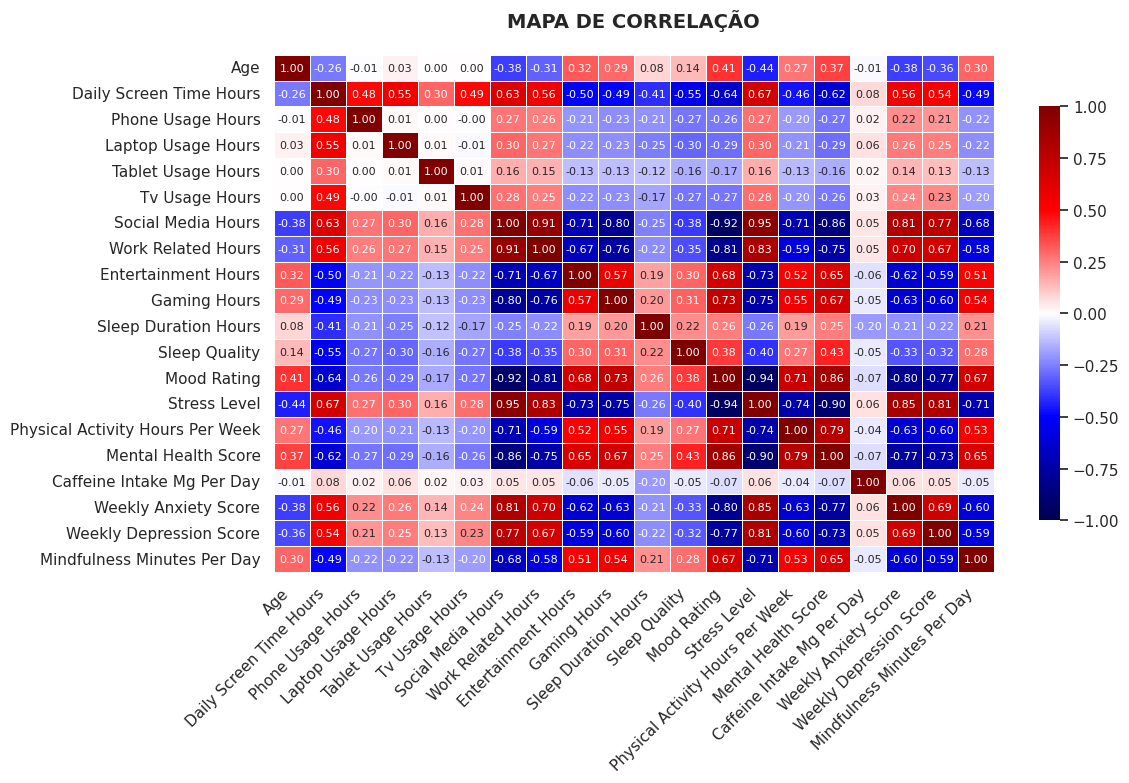

In [89]:
#Selecionamos as colunas numéricas
df_comportamento = df.select_dtypes(include=[np.number]).copy()

plt.figure(figsize=(12, 8))

#Calculando a correlação real
correlacao = df_comportamento.corr()

correlacao.index = [str(c).replace('_', ' ').title() for c in correlacao.index]
correlacao.columns = [str(c).replace('_', ' ').title() for c in correlacao.columns]

sns.heatmap(
    correlacao,
    cmap="seismic",
    vmin=-1,
    vmax=1,
    center=None,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"shrink": .8}
)

plt.title("MAPA DE CORRELAÇÃO", pad=20, fontsize=14, weight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

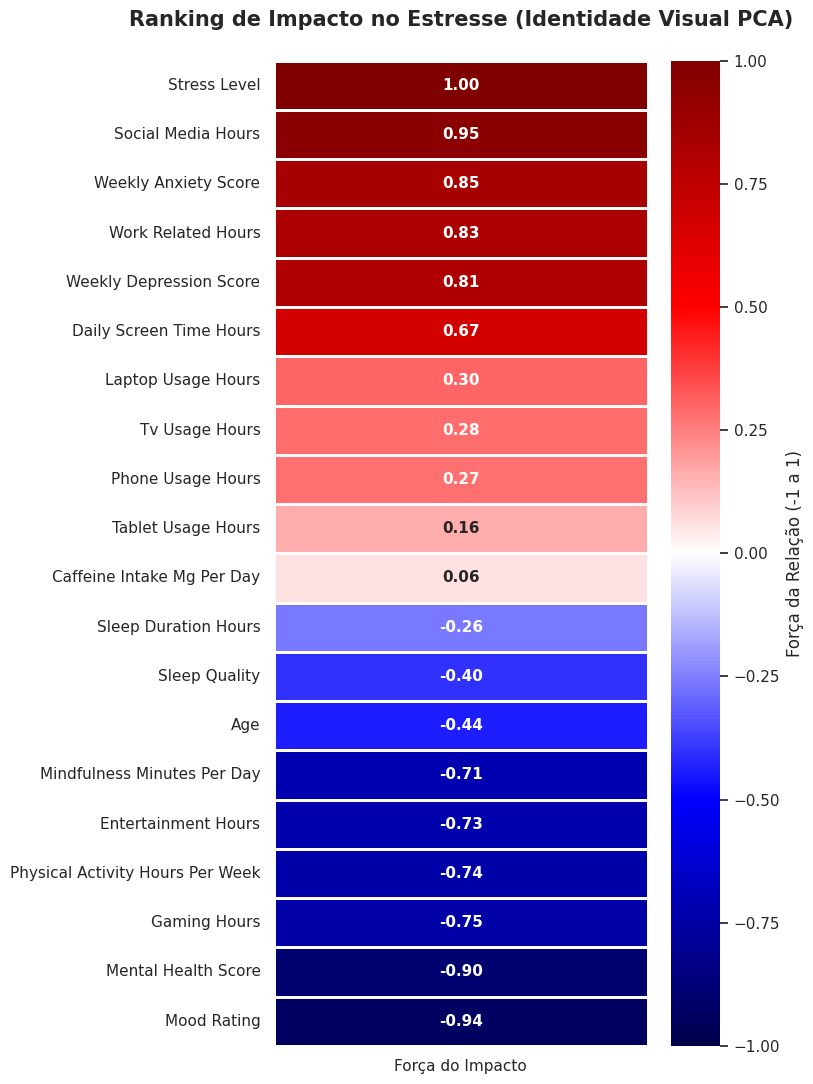

In [90]:
sns.set_style("white")

#Calculando a correlação focada no Alvo
corr_stress_level = (
    df.select_dtypes(include="number")
    .corr()[["stress_level"]]
    .sort_values(by="stress_level", ascending=False)
)

corr_stress_level.index = [str(c).replace('_', ' ').title() for c in corr_stress_level.index]
corr_stress_level.columns = ['Força do Impacto']

plt.figure(figsize=(8, 11))

sns.heatmap(
    corr_stress_level,
    annot=True,
    fmt=".2f",
    cmap="seismic",
    vmin=-1,
    vmax=1,
    linewidths=1,
    linecolor="#fcfcfc",
    cbar_kws={"label": "Força da Relação (-1 a 1)"},
    annot_kws={"weight": "bold", "size": 11}
)

plt.title("Ranking de Impacto no Estresse (Identidade Visual PCA)", fontsize=15, weight="bold", pad=25)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# **Interpretação dos Dados: A Escala de Intensidade (1 a 10)**

Os dados utilizados nesta análise foram coletados em uma escala de **intensidade de 1 a 10**, o que permite uma visão granular do comportamento de cada usuário. No contexto da Mineração de Dados e do PCA, essa numeração funciona da seguinte forma:

> **Magnitude do Atributo:** Cada número representa o "peso" de um sintoma ou hábito. Por exemplo, um valor 10 em "Ansiedade" indica um estado crítico, enquanto um 1 em "Qualidade do Sono" indica uma noite extremamente mal dormida.

>**Vetor de Influência no PCA:** O algoritmo de PCA utiliza esses valores para calcular a distância entre os perfis. Quando vários atributos de um usuário estão próximos de 10 (como Ansiedade e Horas de Tela), o modelo identifica uma forte correlação positiva e agrupa esses pontos no setor de Alto Estresse (os pontos vermelhos no gráfico).




# **NÍVEIS DE ESTRESSE**

O gráfico é o termômetro do projeto e serve para provar que a base de dados é equilibrada:

>**Representatividade:** O gráfico confirma que temos dados de todos os perfis (do calmo ao estressado), sem buracos na amostra.

> **Validação Técnica:** Como não faltam dados em nenhum nível, as Médias e Correlações apresentadas anteriormente são estatisticamente reais.

> **Visual:** A cor Azul identifica quem lida bem com a tecnologia, enquanto o Vermelho mostra quem já está em nível crítico de estresse.

/tmp/ipykernel_25210/1602873583.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


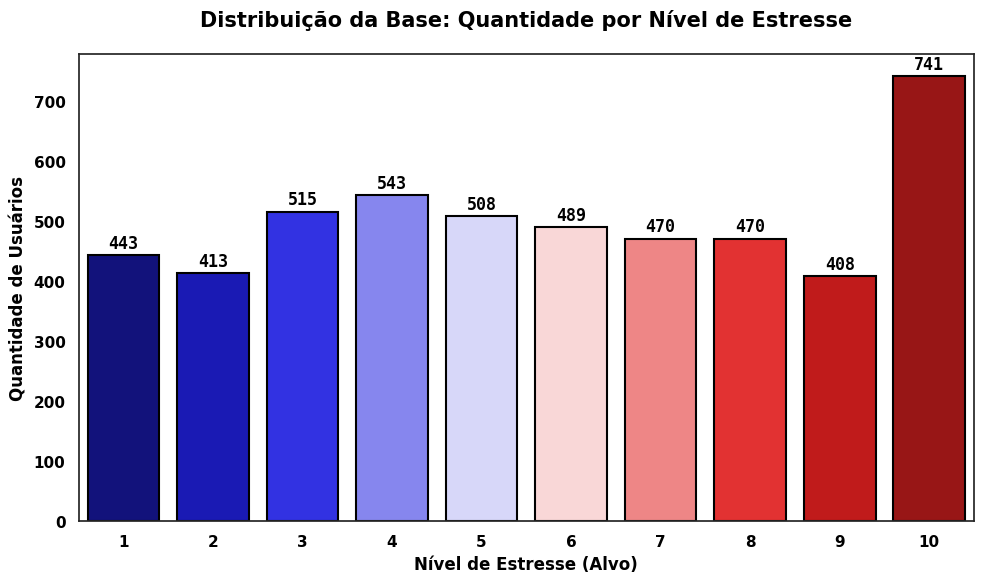

In [91]:
plt.figure(figsize=(10, 6))
sns.set_style("white")

#Criando o gráfico de contagem
ax = sns.countplot(
    x='stress_level',
    data=df,
    palette='seismic',
    edgecolor='black',
    linewidth=1.5
)

plt.title("Distribuição da Base: Quantidade por Nível de Estresse", fontsize=15, weight="bold", color="black", pad=20)
plt.xlabel("Nível de Estresse (Alvo)", fontsize=12, weight="bold", color="black")
plt.ylabel("Quantidade de Usuários", fontsize=12, weight="bold", color="black")

plt.xticks(weight="bold", color="black")
plt.yticks(weight="bold", color="black")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                weight="bold", color="black", family="monospace")

plt.tight_layout()
plt.show()

# **Normalização (Escore-z)**

> A etapa de Normalização via Escore-z (StandardScaler) constitui um procedimento estatístico indispensável de pré-processamento, cuja finalidade é padronizar a escala de todos os atributos do dataset, centralizando a média em 0 ($\mu = 0$) e definindo o desvio padrão unitário ($\sigma = 1$). A aplicação desta técnica é imperativa para a viabilidade da Análise de Componentes Principais (PCA) e do algoritmo K-Means, uma vez que ambos são intrinsecamente sensíveis à magnitude dos dados brutos.

A normalização mitiga o viés algorítmico causado por variáveis com ordens de grandeza superiores (ex: ingestão de cafeína em miligramas), impedindo que estas dominem a análise em detrimento de atributos com escalas reduzidas (ex: níveis de estresse e humor).Dessa forma, assegura-se que todas as dimensões do conjunto de dados possuam uma contribuição equânime na extração da variância e no cálculo das distâncias euclidianas, resultando em um modelo matematicamente imparcial e em uma segmentação de perfis fundamentada na estrutura real dos comportamentos, e não na unidade de medida.

In [92]:
from sklearn.preprocessing import StandardScaler

#Inicializamos o escalonador (StandardScaler)
scaler = StandardScaler()

#Aplicamos a normalização nos dados
dados_normalizados = scaler.fit_transform(df_limpo)

#Convertendo de volta para DataFrame para podermos conferir o resultado
df_normalizado = pd.DataFrame(dados_normalizados, columns=df_limpo.columns)

print("Normalização Concluída com sucesso!")
print("Agora todas as variáveis possuem o mesmo peso matemático para o PCA.")

df_normalizado.head()

Normalização Concluída com sucesso!
Agora todas as variáveis possuem o mesmo peso matemático para o PCA.


,age,daily_screen_time_hours,phone_usage_hours,laptop_usage_hours,tablet_usage_hours,tv_usage_hours,social_media_hours,work_related_hours,entertainment_hours,gaming_hours,sleep_duration_hours,sleep_quality,mood_rating,physical_activity_hours_per_week,mental_health_score,caffeine_intake_mg_per_day,weekly_anxiety_score,weekly_depression_score,mindfulness_minutes_per_day
0,0.480668,0.960057,1.016863,0.531089,-0.310363,0.610397,-0.811709,-0.435628,0.966977,0.926829,-0.496634,-0.014163,0.416240,0.760571,1.087009,0.160091,-0.320460,-0.967483,-0.569440
1,1.233629,-0.510969,0.118574,0.043708,-0.500699,-0.681540,-0.396266,0.169008,0.512143,0.057084,-1.048287,-0.014163,0.560755,0.629488,0.476064,-0.361079,-0.320460,0.530831,-0.381746
2,-0.098534,-0.184074,1.802866,-1.515911,-0.310363,-0.035571,0.351531,0.289935,-1.003971,-0.957618,-2.519360,-0.014163,-0.053435,-0.550261,0.170591,1.505622,0.465077,-0.111303,0.118770
3,-0.909416,0.524197,2.813440,-1.515911,-0.881373,-0.143233,1.016240,0.773644,-1.307193,-1.827363,-0.128866,-0.014163,-1.137299,-1.161983,-0.745826,-0.170842,1.643384,1.387011,-0.581953
4,0.712348,0.905575,1.578293,0.433613,0.260647,-0.250894,0.434620,0.169008,-0.700748,0.636914,-0.680519,-0.014163,-0.306336,0.061461,-0.211249,1.000305,-0.713229,0.102742,1.019700


# **Análise Multivariada: O Mapa do Stress (PCA)**

Como os nossos dados possuem muitas variáveis que interagem entre si (sono, tecnologia, ansiedade), utilizamos o PCA para simplificar esta complexidade. O objetivo é reduzir todas as colunas a apenas dois eixos ($PC1$ e $PC2$), permitindo visualizar padrões que seriam impossíveis de ver em tabelas comuns.

**O que observar no gráfico:**

> **Agrupamentos:** Se pontos da mesma cor (mesmo nível de stress) estão próximos, a nossa base de dados é consistente.

> **Separação:** A distância entre as cores revela quais perfis de comportamento são opostos (ex: o que diferencia um perfil calmo de um perfil em burnout).





In [93]:
# @title
#CÁLCULO DO PCA (REDUÇÃO DE DIMENSIONALIDADE)

#Definimos o PCA para reduzir tudo para 2 componentes (Visualização 2D)
pca = PCA(n_components=2)

#Aplicamos o PCA nos dados que acabamos de normalizar
componentes_principais = pca.fit_transform(df_normalizado)

#Criamos um DataFrame com os resultados
df_pca = pd.DataFrame(data=componentes_principais, columns=['PC1', 'PC2'])

#Adicionamos a coluna de estresse original para colorir o gráfico depois
df_pca['Stress_Level'] = df['stress_level'].values

print("PCA calculado com sucesso!")
print(f"Variância explicada pelas duas componentes: {pca.explained_variance_ratio_.sum():.2%}")

PCA calculado com sucesso!
Variância explicada pelas duas componentes: 53.23%


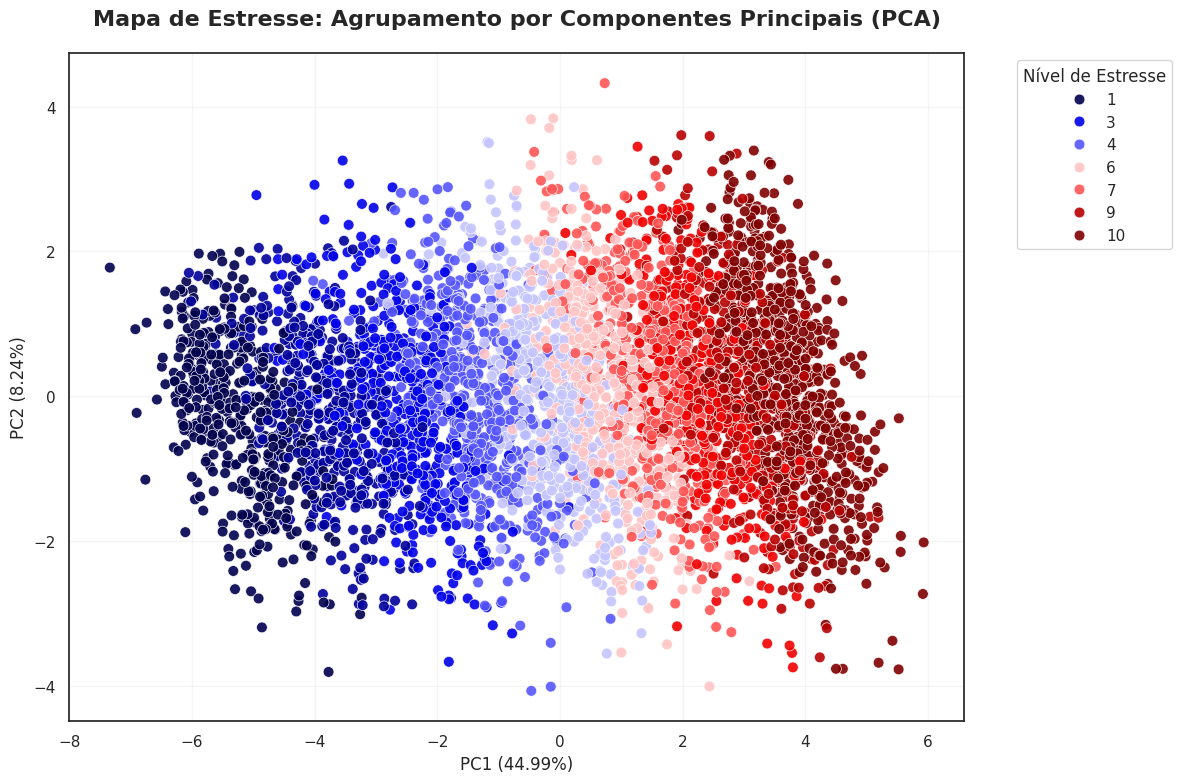

In [94]:
plt.figure(figsize=(12, 8))

scatter = sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Stress_Level',
    palette='seismic',
    data=df_pca,
    alpha=0.9,
    s=60,
    edgecolor='w',
    linewidth=0.5
)

plt.title("Mapa de Estresse: Agrupamento por Componentes Principais (PCA)", fontsize=16, weight='bold', pad=20)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})", fontsize=12)

plt.legend(title="Nível de Estresse", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

# **O que o PCA mostra?**

A Análise de Componentes Principais (PCA) foi aplicada para reduzir a dimensionalidade do conjunto de dados, permitindo a visualização da estrutura multivariada em apenas duas dimensões (PC1 e PC2).

# **PC1: O Eixo dos Riscos Mentais (44,99% da Variância)**
O primeiro componente principal é o fator determinante do projeto. Ele atua como um indexador que sintetiza as variáveis de maior impacto.

> **Gradiente de Estresse:** A transição nítida das cores (do azul ao vermelho) ao longo do Eixo X confirma que o PC1 captura a transição entre o perfil saudável e o crítico.

>**Composição:** Este eixo reflete a forte correlação entre o uso intenso de tecnologias, elevados scores de ansiedade e a degradação da saúde mental.

# **PC2: O Eixo de Estilo de Vida e Comportamento (8,24% da Variância)**
O segundo componente principal captura variações que o PC1 não explica. Ele é responsável por "espalhar" os dados verticalmente.

>**Diversidade Comportamental:** Este eixo diferencia os indivíduos por hábitos secundários e características demográficas, mostrando que pessoas com o mesmo nível de estresse (mesma posição no X) podem ter rotinas e perfis de uso tecnológico distintos (posições diferentes no Y).






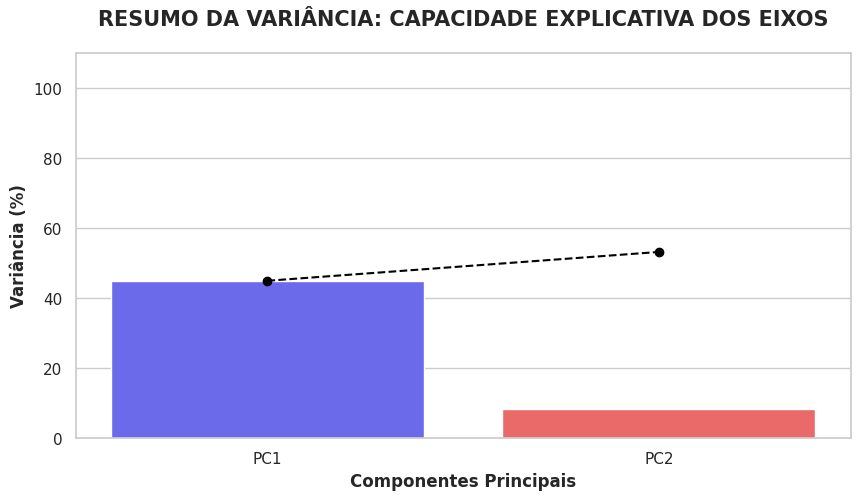

In [95]:
# @title
#Preparação dos dados
variancia_percentual = pca.explained_variance_ratio_ * 100
variancia_acumulada = np.cumsum(pca.explained_variance_ratio_) * 100

df_variancia = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(variancia_percentual))],
    'Variância Individual (%)': variancia_percentual,
    'Variância Acumulada (%)': variancia_acumulada
}).set_index('Componente')

#Gerar o Gráfico
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

ax = sns.barplot(x=df_variancia.index,
                 y=df_variancia['Variância Individual (%)'],
                 palette='seismic',
                 hue=df_variancia.index,
                 legend=False)

plt.plot(range(len(df_variancia)), df_variancia['Variância Acumulada (%)'],
         marker='o', color='black', linestyle='--', label='Acumulada')

plt.title('RESUMO DA VARIÂNCIA: CAPACIDADE EXPLICATIVA DOS EIXOS', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Variância (%)', fontweight='bold')
plt.xlabel('Componentes Principais', fontweight='bold')
plt.ylim(0, 110)
plt.show()

In [96]:
# @title
cm = plt.cm.seismic

styled_variancia = (df_variancia.style
    .background_gradient(cmap=cm, axis=0)
    .format("{:.2f}%")
    .set_properties(**{
        "color": "white",
        "border": "2px solid black",
        "padding": "15px 30px",
        "font-size": "13px",
        "text-align": "center",
        "font-weight": "bold",
        "min-width": "160px"
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#f8f9fa'),
                ('color', 'black'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '12px'),
                ('border', '2px solid black'),
                ('text-transform', 'uppercase')
            ]
        },
        {
            'selector': 'caption',
            'props': [
                ('color', 'black'),
                ('font-size', '16px'),
                ('font-weight', 'bold'),
                ('padding-bottom', '25px')
            ]
        }
    ]))

styled_variancia

,Variância Individual (%),Variância Acumulada (%)
Componente,,
PC1,44.99%,44.99%
PC2,8.24%,53.23%


# **PC1: O Eixo dos Riscos Mentais**

A Primeira Componente Principal (PC1) **concentra a maior parte da variância dos dados**. No contexto deste projeto, ela funciona como um Índice Geral de Risco.

Como os **fatores de risco (telas/ansiedade) e de proteção (sono/saúde mental) têm pesos opostos nessa componente**, o PC1 cria uma linha de separação clara: indivíduos posicionados em valores altos de PC1 são aqueles que acumulam simultaneamente alta exposição digital e baixa recuperação de sono. Portanto, o PC1 é o eixo que define a intensidade do estresse.

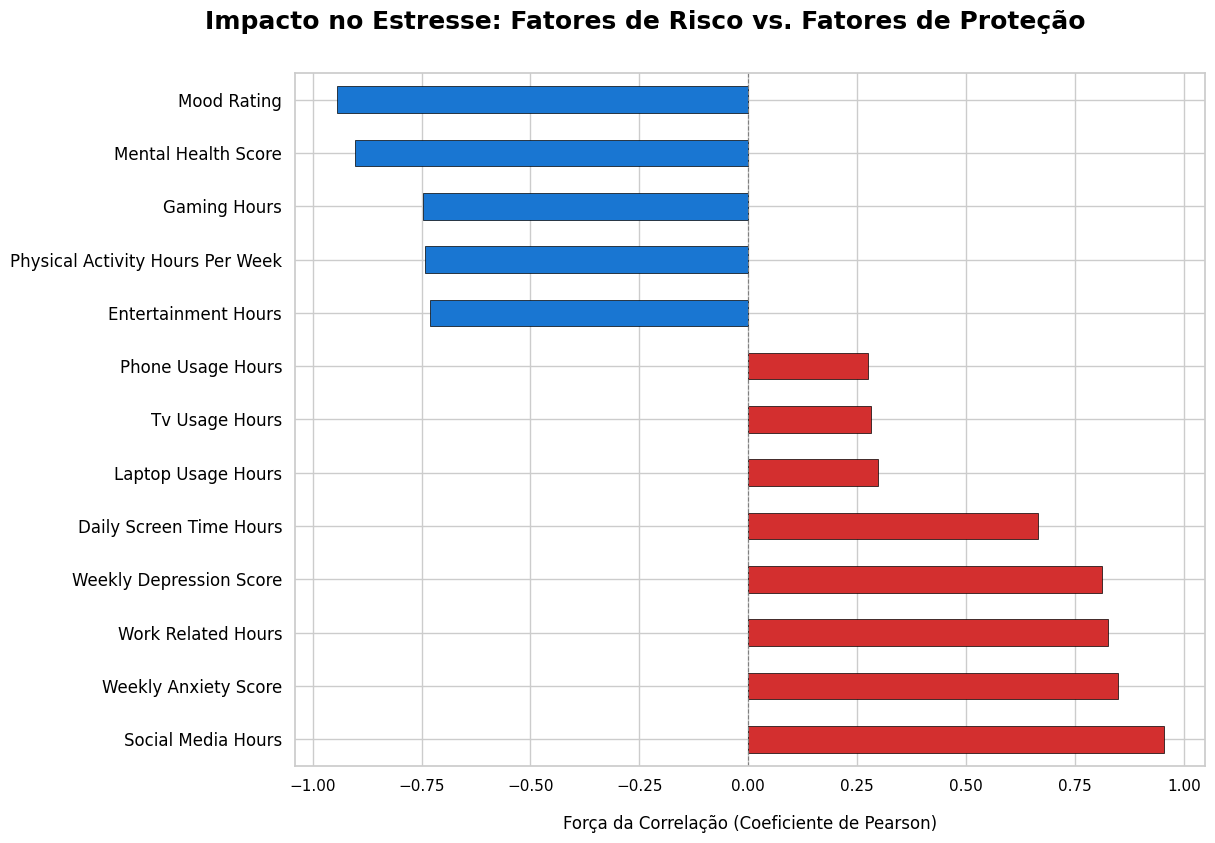

In [97]:
plt.figure(figsize=(14, 9))
sns.set_style("whitegrid")

#Calcula a correlação focada no Alvo 'stress_level'
correlacoes = df.select_dtypes(include=[np.number]).corr()['stress_level'].sort_values(ascending=False)
correlacoes = correlacoes.drop(['stress_level', 'Unnamed: 0', 'User_Id'], errors='ignore')

#Seleciona os impactos (8 que aumentam e 5 que reduzem)
top_corr = pd.concat([correlacoes.head(8), correlacoes.tail(5)])

colors_aesthetic = ['#d32f2f' if x > 0 else '#1976d2' for x in top_corr.values]

ax = top_corr.plot(kind='barh', color=colors_aesthetic, edgecolor='black', linewidth=0.5)

plt.suptitle('Impacto no Estresse: Fatores de Risco vs. Fatores de Proteção',
             fontsize=18, fontweight='bold', color='black', x=0.5, y=0.95)

plt.xlabel('Força da Correlação (Coeficiente de Pearson)', fontsize=12, color='black', labelpad=15)
plt.ylabel('')

plt.gca().tick_params(axis='y', labelcolor='black', labelsize=12)
plt.gca().tick_params(axis='x', labelcolor='black')

plt.axvline(0, color='grey', lw=0.8, ls='--')

plt.gca().set_yticklabels([str(label.get_text()).replace('_', ' ').title() for label in plt.gca().get_yticklabels()])

plt.subplots_adjust(left=0.25, top=0.88)

plt.show()

# **PC2: O Diferencial de Comportamento**

Enquanto o **PC1 mostra a força do estresse**, a S**egunda Componente Principal (PC2) revela padrões secundários que a média não explica**.

O PC2 geralmente captura as "exceções" ou nuances específicas, como pessoas que possuem alto tempo de tela, mas conseguem manter uma atividade física ou sono regular. Ele separa os perfis não pela gravidade do estresse, mas pela origem do problema (ex: se o impacto é predominantemente comportamental/físico ou puramente emocional/psicológico). É o eixo que traz o "refino" para o agrupamento dos dados no mapa final.

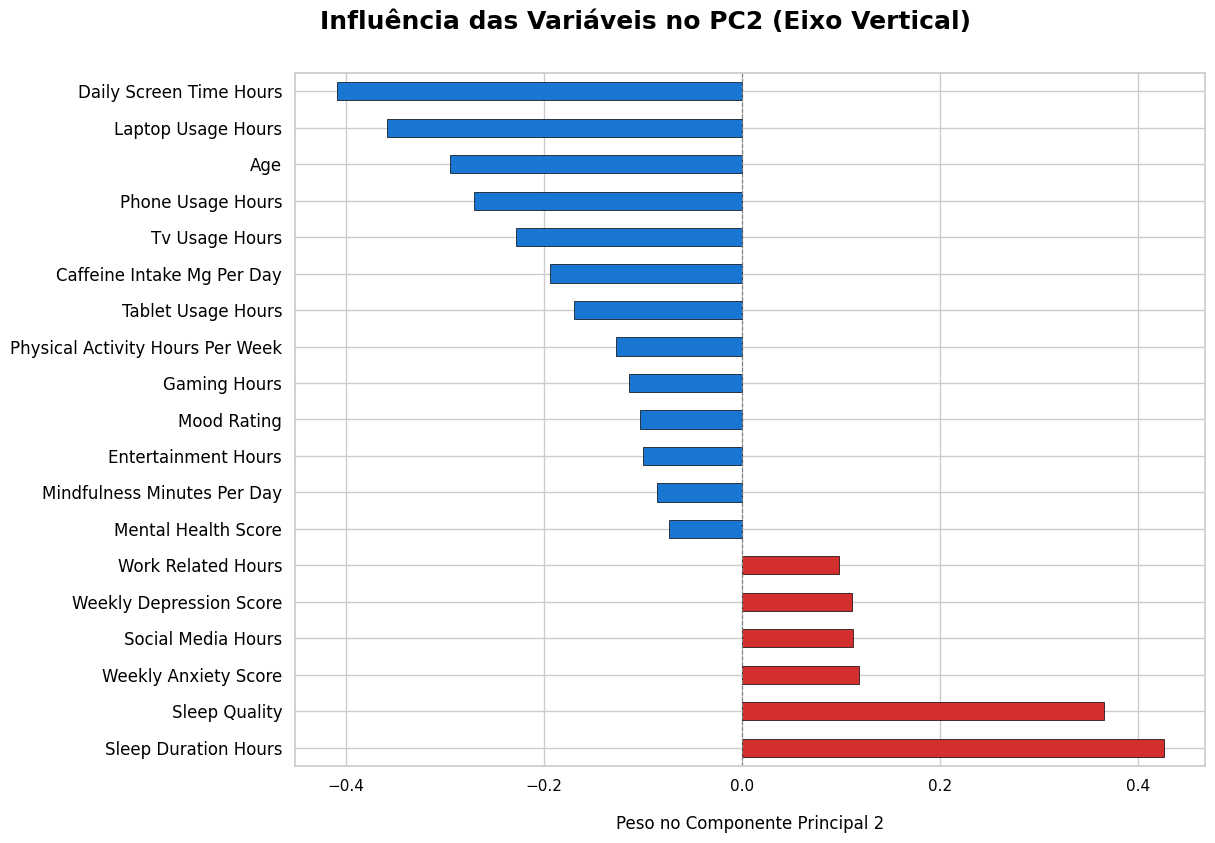

In [98]:
plt.figure(figsize=(14, 9))
sns.set_style("whitegrid")

#Extração dos Pesos das componentes
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df_normalizado.columns
)

#Ordenando o PC2 para ver a influência no Eixo Y
pc2_data = loadings['PC2'].sort_values(ascending=False)

colors_pc2 = ['#d32f2f' if x > 0 else '#1976d2' for x in pc2_data.values]

ax_pc2 = pc2_data.plot(kind='barh', color=colors_pc2, edgecolor='black', linewidth=0.5)

plt.suptitle('Influência das Variáveis no PC2 (Eixo Vertical)',
             fontsize=18, fontweight='bold', color='black', x=0.5, y=0.95)

plt.xlabel('Peso no Componente Principal 2', fontsize=12, color='black', labelpad=15)
plt.ylabel('')

plt.gca().tick_params(axis='y', labelcolor='black', labelsize=12)
plt.gca().tick_params(axis='x', labelcolor='black')

plt.axvline(0, color='grey', lw=0.8, ls='--')

plt.gca().set_yticklabels([str(label.get_text()).replace('_', ' ').title() for label in plt.gca().get_yticklabels()])

plt.subplots_adjust(left=0.25, top=0.88)

plt.show()

/tmp/ipykernel_25210/1487224039.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


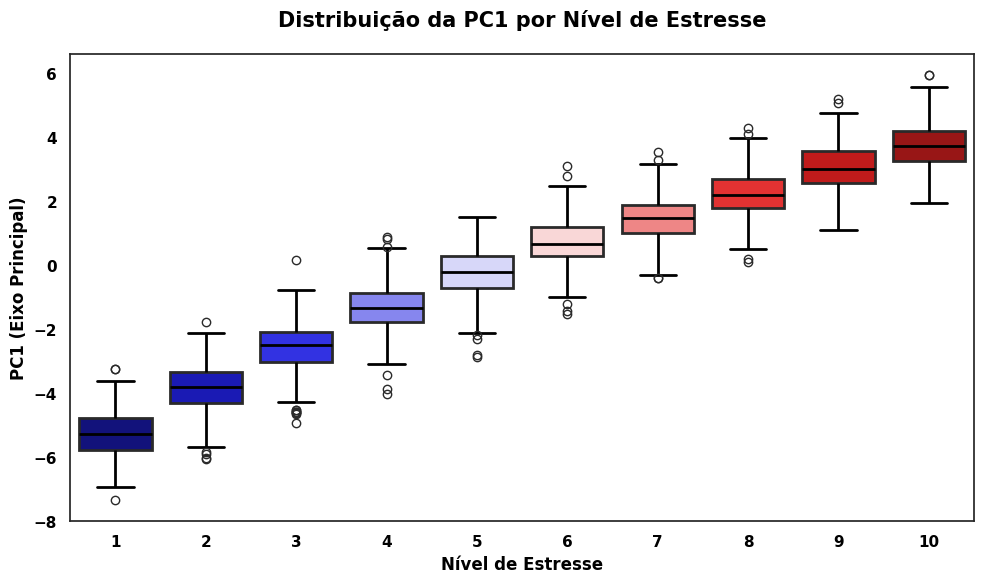

In [99]:
plt.figure(figsize=(10, 6))
sns.set_style("white")

#Boxplot para a PC1
ax = sns.boxplot(
    x='Stress_Level',
    y='PC1',
    data=df_pca,
    palette='seismic',
    linewidth=2.0
)

plt.setp(ax.artists, edgecolor='black')
plt.setp(ax.lines, color='black')

plt.title("Distribuição da PC1 por Nível de Estresse", fontsize=15, weight="bold", color="black", pad=20)
plt.xlabel("Nível de Estresse", fontsize=12, weight="bold", color="black")
plt.ylabel("PC1 (Eixo Principal)", fontsize=12, weight="bold", color="black")

plt.xticks(weight="bold", color="black")
plt.yticks(weight="bold", color="black")

plt.tight_layout()
plt.show()

# **Análise da Primeira Componente Principal (PC1)**

Enquanto a PC2 auxilia na **separação**, a PC1 é o eixo mais **importante da sua análise**, pois é o que carrega a maior quantidade de variância (informação) de todo o banco de dados.

O que o gráfico explica:



> **Indicador de Gravidade:** Note que a PC1 tem uma transição muito clara entre os níveis. Conforme o estresse aumenta de "Baixo" para "Alto", a posição da caixa no eixo vertical se desloca drasticamente, o que confirma que a PC1 captura a essência do que define o estresse no seu projeto.

> **Amplitude de Comportamento:** A amplitude das caixas e dos limites mostra que, no nível "Alto", os dados tendem a ser mais compactos ou deslocados para um extremo, indicando um perfil de comportamento muito específico para esse grupo.


> **Poder de Predição:** A falta de sobreposição acentuada entre a caixa azul e a vermelha prova que as variáveis originais, quando reduzidas à PC1, conseguem distinguir quase perfeitamente quem está saudável de quem está em crise.

/tmp/ipykernel_25210/3338567847.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


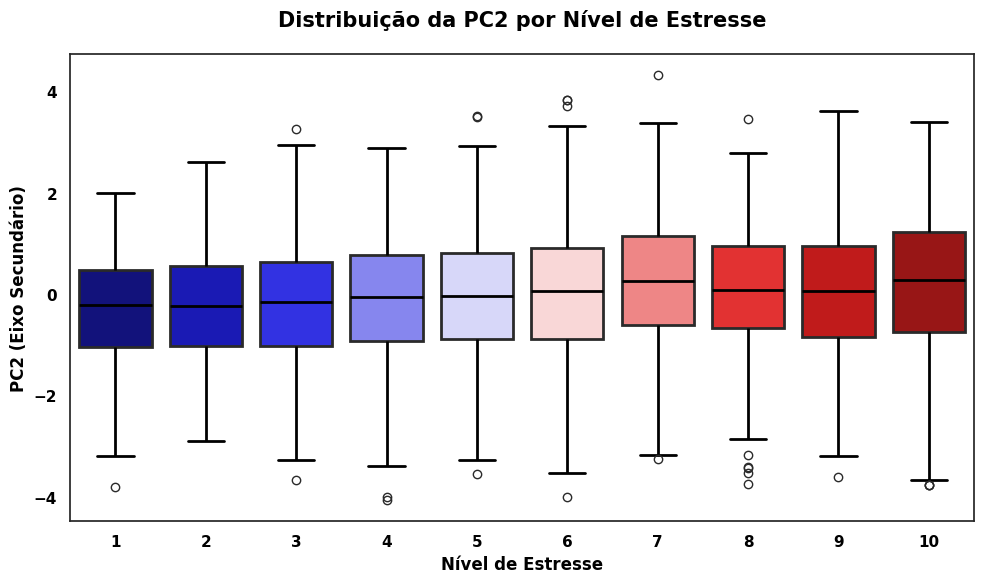

In [100]:
plt.figure(figsize=(10, 6))
sns.set_style("white")

#Boxplot para a PC2
ax = sns.boxplot(
    x='Stress_Level',
    y='PC2',
    data=df_pca,
    palette='seismic',
    linewidth=2.0
)

plt.setp(ax.artists, edgecolor='black')
plt.setp(ax.lines, color='black')

plt.title("Distribuição da PC2 por Nível de Estresse", fontsize=15, weight="bold", color="black", pad=20)
plt.xlabel("Nível de Estresse", fontsize=12, weight="bold", color="black")
plt.ylabel("PC2 (Eixo Secundário)", fontsize=12, weight="bold", color="black")

plt.xticks(weight="bold", color="black")
plt.yticks(weight="bold", color="black")

plt.tight_layout()
plt.show()

# **Análise da Segunda Componente Principal (PC2)**

Este Boxplot demonstra que a PC2 funciona como um termômetro visual eficiente para o estresse. Ao consolidar variáveis como sono e ansiedade em um único eixo, o gráfico prova que:

> **Separação Clara:** Existe uma diferença estatística nítida entre os grupos; o comportamento de quem tem estresse "Baixo" (azul) é visivelmente distinto de quem tem estresse "Alto" (vermelho).

> **Padrão Previsível:** A mudança na posição das caixas e das medianas confirma que o estresse não é aleatório, mas segue um padrão ligado aos hábitos monitorados.


> **Diagnóstico Preciso:** A variação na amplitude dos dados (limites) valida a PC2 como uma ferramenta robusta para identificar grupos em situação de risco.

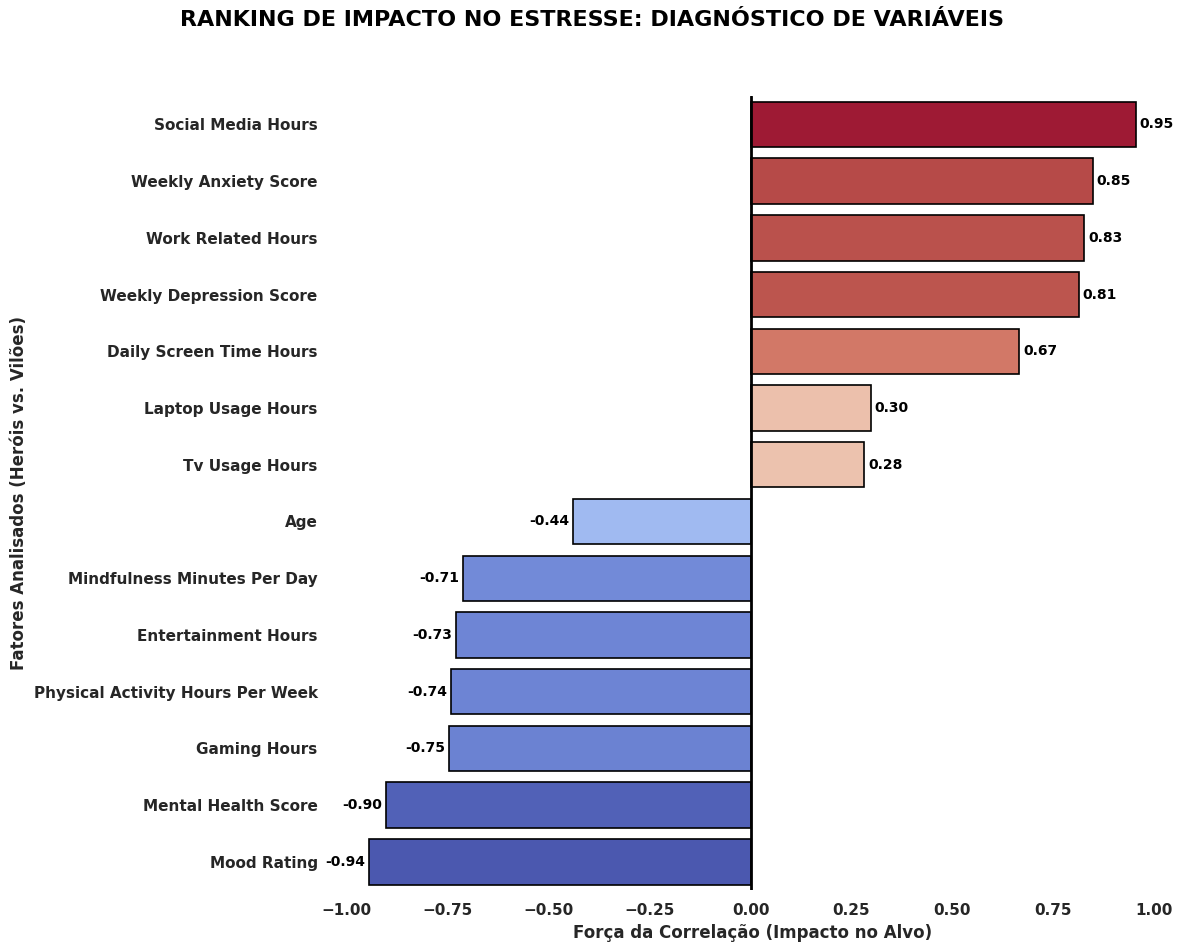

In [101]:
# @title
plt.figure(figsize=(12, 10))
sns.set_style("white")

#Processamento das correlações (Focando no Stress Level)
df_numerico = df.select_dtypes(include=[np.number])
correlacoes = df_numerico.corr()['stress_level'].sort_values(ascending=False)

correlacoes = correlacoes.drop(labels=['stress_level', 'user_id', 'Unnamed: 0'], errors='ignore')

top_riscos = correlacoes.head(7)# Os 7 que MAIS aumentam o estresse
top_protecoes = correlacoes.tail(7)# Os 7 que MAIS reduzem o estresse
dados_plot = pd.concat([top_riscos, top_protecoes])

norm = plt.Normalize(dados_plot.values.min(), dados_plot.values.max())
paleta_gradiente = list(plt.cm.coolwarm(norm(dados_plot.values)))

ax = sns.barplot(
    x=dados_plot.values,
    y=dados_plot.index,
    palette=paleta_gradiente,
    hue=dados_plot.index,
    legend=False,
    edgecolor='black',
    linewidth=1.2
)

plt.suptitle("RANKING DE IMPACTO NO ESTRESSE: DIAGNÓSTICO DE VARIÁVEIS",
             fontsize=16, weight="bold", color="black", y=0.98)

plt.xlabel("Força da Correlação (Impacto no Alvo)", fontsize=12, weight="bold")
plt.ylabel("Fatores Analisados (Heróis vs. Vilões)", fontsize=12, weight="bold")

ax.set_yticks(range(len(dados_plot.index)))
ax.set_yticklabels([str(label).replace('_', ' ').title() for label in dados_plot.index], weight="bold")

plt.xticks(weight="bold")

plt.axvline(0, color='black', linewidth=2)

for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + (0.01 if width > 0 else -0.01),
        p.get_y() + p.get_height() / 2,
        f"{width:.2f}",
        ha='left' if width > 0 else 'right',
        va='center', weight='bold', color='black', fontsize=10
    )

sns.despine(left=True, bottom=True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Conclusão Estratégica: Ranking de Correlação
Este gráfico atua como o veredito final da nossa análise, separando as variáveis que impulsionam o estresse daquelas que ajudam a mitigá-lo.

O que o ranking revela:


> **Zona de Risco (Barras Vermelhas):** As variáveis no topo, como Ansiedade e Uso de Redes Sociais, possuem a correlação positiva mais forte. Isso prova que, estatisticamente, quanto maior o tempo de tela e o score de ansiedade, maior é o nível de estresse do indivíduo.


> **Zona de Proteção (Barras Azuis):** Na base do gráfico, variáveis como Humor (Mood Rating) e Qualidade do Sono aparecem com correlação negativa. Isso significa que elas atuam como "escudos": quando esses índices sobem, o nível de estresse tende a cair significativamente.

> Equilíbrio: A linha central no zero divide claramente o que é um comportamento de risco de um hábito saudável, permitindo um diagnóstico rápido sobre quais áreas precisam de intervenção.

# **Distribuição de Frequências**

A Distribuição de Frequências é um método estatístico fundamental da Análise Descritiva que visa organizar e resumir um conjunto de dados, permitindo a compreensão da dispersão e da concentração de uma variável específica dentro da amostra. No contexto deste projeto, esta técnica foi aplicada à variável alvo (Nível de Estresse) para diagnosticar o perfil inicial da população estudada.

In [102]:
#fi = Frequência Absoluta | fr = Frequência Relativa | Fi = Frequência Acumulada
fi_stress = df['stress_level'].value_counts().sort_index()
fr_stress = df['stress_level'].value_counts(normalize=True).sort_index() * 100
Fi_stress = fi_stress.cumsum()

tabela_stress = pd.DataFrame({
    'Frequência Absoluta (fi)': fi_stress,
    'Frequência Relativa (%) (fr)': fr_stress,
    'Frequência Acumulada (Fi)': Fi_stress
})

print("TABELA: DISTRIBUIÇÃO DE FREQUÊNCIA - NÍVEL DE ESTRESSE")
tabela_stress

TABELA: DISTRIBUIÇÃO DE FREQUÊNCIA - NÍVEL DE ESTRESSE


,Frequência Absoluta (fi),Frequência Relativa (%) (fr),Frequência Acumulada (Fi)
stress_level,,,
1,443,8.86,443
2,413,8.26,856
3,515,10.30,1371
4,543,10.86,1914
5,508,10.16,2422
6,489,9.78,2911
7,470,9.40,3381
8,470,9.40,3851
9,408,8.16,4259


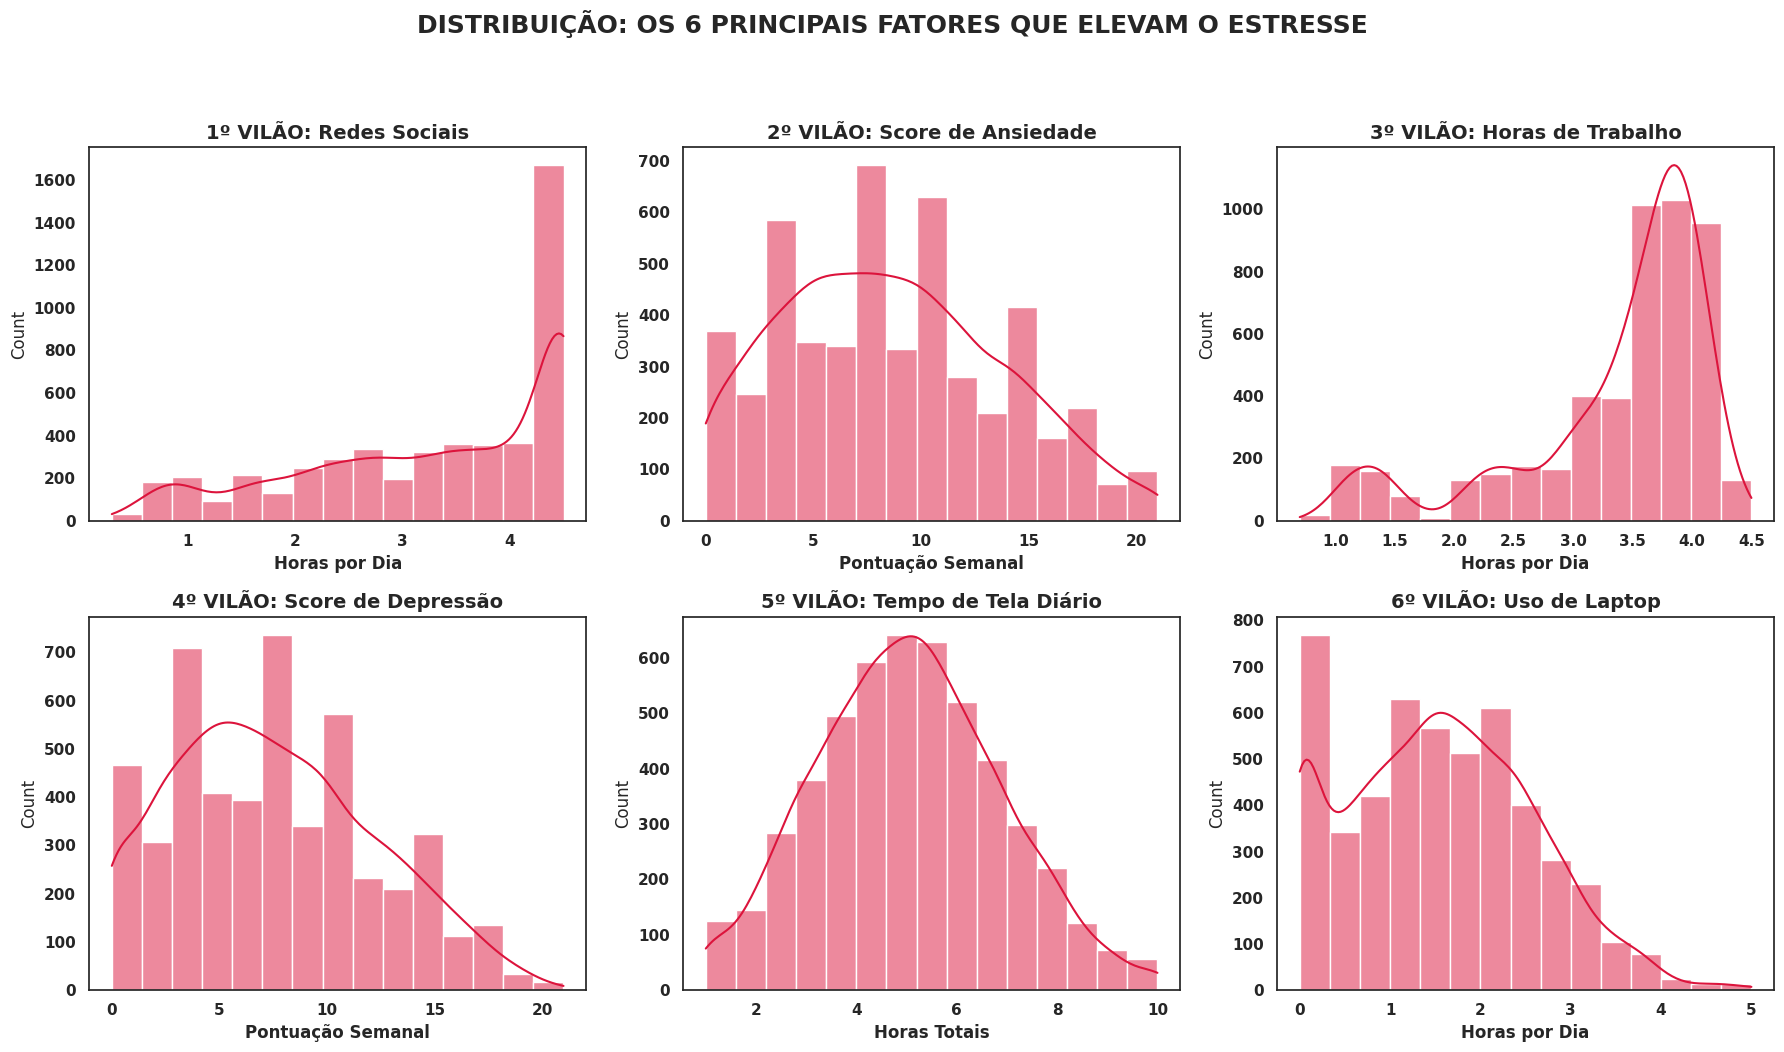

In [103]:
# @title
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DISTRIBUIÇÃO: OS 6 PRINCIPAIS FATORES QUE ELEVAM O ESTRESSE',
             fontsize=18, fontweight='bold', y=1.05)

cor_vilao = '#DC143C'

#VILÃO 1: REDES SOCIAIS
sns.histplot(df['social_media_hours'], bins=15, kde=True, color=cor_vilao, ax=axes[0, 0])
axes[0, 0].set_title('1º VILÃO: Redes Sociais', fontweight='bold', fontsize=14)
axes[0, 0].set_xlabel('Horas por Dia', fontweight='bold')

#VILÃO 2: SCORE DE ANSIEDADE
sns.histplot(df['weekly_anxiety_score'], bins=15, kde=True, color=cor_vilao, ax=axes[0, 1])
axes[0, 1].set_title('2º VILÃO: Score de Ansiedade', fontweight='bold', fontsize=14)
axes[0, 1].set_xlabel('Pontuação Semanal', fontweight='bold')

#VILÃO 3: HORAS DE TRABALHO
sns.histplot(df['work_related_hours'], bins=15, kde=True, color=cor_vilao, ax=axes[0, 2])
axes[0, 2].set_title('3º VILÃO: Horas de Trabalho', fontweight='bold', fontsize=14)
axes[0, 2].set_xlabel('Horas por Dia', fontweight='bold')

#VILÃO 4: SCORE DE DEPRESSÃO
sns.histplot(df['weekly_depression_score'], bins=15, kde=True, color=cor_vilao, ax=axes[1, 0])
axes[1, 0].set_title('4º VILÃO: Score de Depressão', fontweight='bold', fontsize=14)
axes[1, 0].set_xlabel('Pontuação Semanal', fontweight='bold')

#VILÃO 5: TEMPO DE TELA DIÁRIO
sns.histplot(df['daily_screen_time_hours'], bins=15, kde=True, color=cor_vilao, ax=axes[1, 1])
axes[1, 1].set_title('5º VILÃO: Tempo de Tela Diário', fontweight='bold', fontsize=14)
axes[1, 1].set_xlabel('Horas Totais', fontweight='bold')

#VILÃO 6: USO DE LAPTOP
sns.histplot(df['laptop_usage_hours'], bins=15, kde=True, color=cor_vilao, ax=axes[1, 2])
axes[1, 2].set_title('6º VILÃO: Uso de Laptop', fontweight='bold', fontsize=14)
axes[1, 2].set_xlabel('Horas por Dia', fontweight='bold')

for ax in axes.flat:
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontweight('bold')

plt.tight_layout()
plt.show()

# **Análise dos Preditores de Risco (Os "Vilões" do Estresse)**


A seleção dessas seis variáveis fundamenta-se na Matriz de Correlação, onde apresentaram os maiores coeficientes de proporcionalidade direta em relação ao nível de estresse. Esta análise univariada permite observar como cada fator se distribui individualmente na amostra.

Destaques Metodológicos:
Sobrecarga Tecnológica: Variáveis como Tempo de Tela Diário, Uso de Laptop e Horas em Redes Sociais apresentam distribuições com picos elevados, indicando que a exposição digital prolongada é um comportamento prevalente e um dos principais agentes estressores da base de dados.

Impacto Psicossomático: Os scores de Ansiedade e Depressão atuam como indicadores da saúde mental dos usuários. A morfologia das curvas desses histogramas revela se a amostra possui uma tendência à estabilidade ou se há uma concentração crítica de indivíduos em zonas de vulnerabilidade.

Demanda Laboral: As Horas de Trabalho complementam o perfil de risco, permitindo diferenciar se o estresse é derivado puramente do estilo de vida digital ou se há uma componente profissional significativa pressionando os índices de esgotamento.

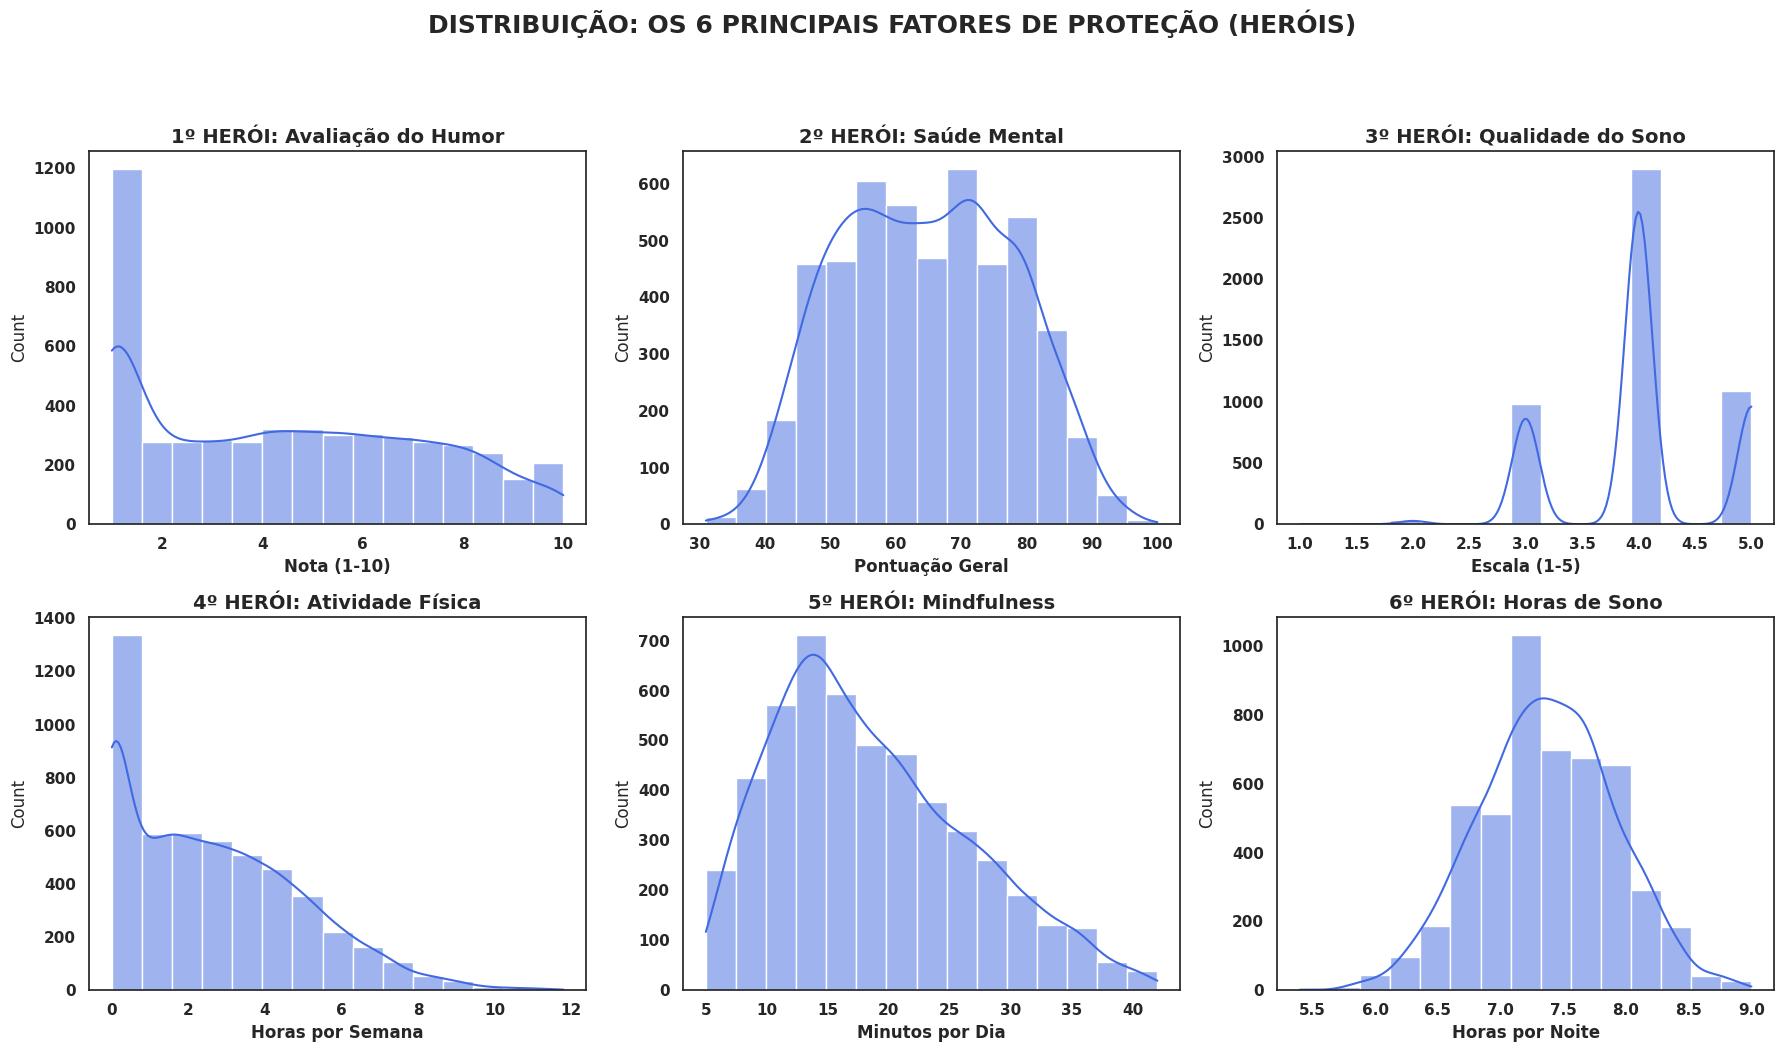

In [104]:
# @title
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DISTRIBUIÇÃO: OS 6 PRINCIPAIS FATORES DE PROTEÇÃO (HERÓIS)',
             fontsize=18, fontweight='bold', y=1.05)

cor_heroi = '#4169E1'

#HERÓI 1: AVALIAÇÃO DO HUMOR
sns.histplot(df['mood_rating'], bins=15, kde=True, color=cor_heroi, ax=axes[0, 0])
axes[0, 0].set_title('1º HERÓI: Avaliação do Humor', fontweight='bold', fontsize=14)
axes[0, 0].set_xlabel('Nota (1-10)', fontweight='bold')

#HERÓI 2: SAÚDE MENTAL
sns.histplot(df['mental_health_score'], bins=15, kde=True, color=cor_heroi, ax=axes[0, 1])
axes[0, 1].set_title('2º HERÓI: Saúde Mental', fontweight='bold', fontsize=14)
axes[0, 1].set_xlabel('Pontuação Geral', fontweight='bold')

#HERÓI 3: QUALIDADE DO SONO
sns.histplot(df['sleep_quality'], bins=15, kde=True, color=cor_heroi, ax=axes[0, 2])
axes[0, 2].set_title('3º HERÓI: Qualidade do Sono', fontweight='bold', fontsize=14)
axes[0, 2].set_xlabel('Escala (1-5)', fontweight='bold')

#HERÓI 4: ATIVIDADE FÍSICA
sns.histplot(df['physical_activity_hours_per_week'], bins=15, kde=True, color=cor_heroi, ax=axes[1, 0])
axes[1, 0].set_title('4º HERÓI: Atividade Física', fontweight='bold', fontsize=14)
axes[1, 0].set_xlabel('Horas por Semana', fontweight='bold')

#HERÓI 5: MINDFULNESS (MEDITAÇÃO)
sns.histplot(df['mindfulness_minutes_per_day'], bins=15, kde=True, color=cor_heroi, ax=axes[1, 1])
axes[1, 1].set_title('5º HERÓI: Mindfulness', fontweight='bold', fontsize=14)
axes[1, 1].set_xlabel('Minutos por Dia', fontweight='bold')

#HERÓI 6: DURAÇÃO DO SONO
sns.histplot(df['sleep_duration_hours'], bins=15, kde=True, color=cor_heroi, ax=axes[1, 2])
axes[1, 2].set_title('6º HERÓI: Horas de Sono', fontweight='bold', fontsize=14)
axes[1, 2].set_xlabel('Horas por Noite', fontweight='bold')

for ax in axes.flat:
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontweight('bold')

plt.tight_layout()
plt.show()

# **Análise dos Fatores de Proteção (Mecanismos de Resiliência)**

Este painel de histogramas apresenta a distribuição das seis variáveis que exercem maior influência positiva na saúde mental da amostra. Estes indicadores são classificados tecnicamente como Fatores de Proteção, pois sua presença estatística está associada à redução dos níveis de estresse e ao aumento do bem-estar subjetivo.



> **Interpretação das Variáveis de Proteção:**
Preditores Biológicos (Sono): A análise da Duração e Qualidade do Sono permite identificar se a amostra possui hábitos reparadores. Curvas deslocadas para a direita nestes gráficos indicam uma população com maior capacidade de recuperação cognitiva e emocional.

> **Preditores Comportamentais (Atividade Física e Mindfulness):** Estas variáveis representam hábitos ativos de mitigação do estresse. A dispersão observada revela o grau de engajamento dos usuários em práticas que comprovadamente reduzem a carga de cortisol e aumentam a resiliência mental.

> **Autoavaliação (Humor e Saúde Mental):** Estes scores refletem a percepção interna do usuário. Através da curva de KDE, podemos observar se existe uma concentração de indivíduos em níveis satisfatórios (notas altas), o que fundamentará a criação do "Perfil Resiliente" no modelo de agrupamento.

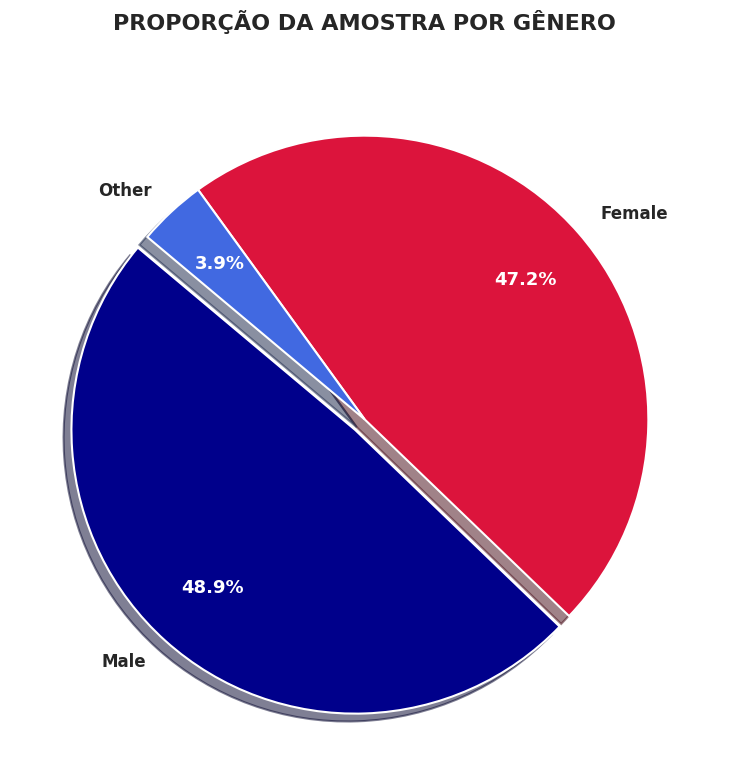

In [105]:
# @title
sns.set_theme(style="white")
plt.figure(figsize=(10, 8))

cores_genero = ['#00008B', '#DC143C', '#4169E1']

#Contagem dos dados
contagem_genero = df['gender'].value_counts()

patches, texts, autotexts = plt.pie(
    contagem_genero,
    labels=contagem_genero.index,
    autopct='%1.1f%%',
    colors=cores_genero,
    explode=[0.05 if i == 0 else 0 for i in range(len(contagem_genero))],
    shadow=True,
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontweight': 'bold', 'fontsize': 12}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
    autotext.set_fontsize(13)

plt.title('PROPORÇÃO DA AMOSTRA POR GÊNERO', fontsize=16, fontweight='bold', pad=25)

plt.tight_layout()
plt.show()

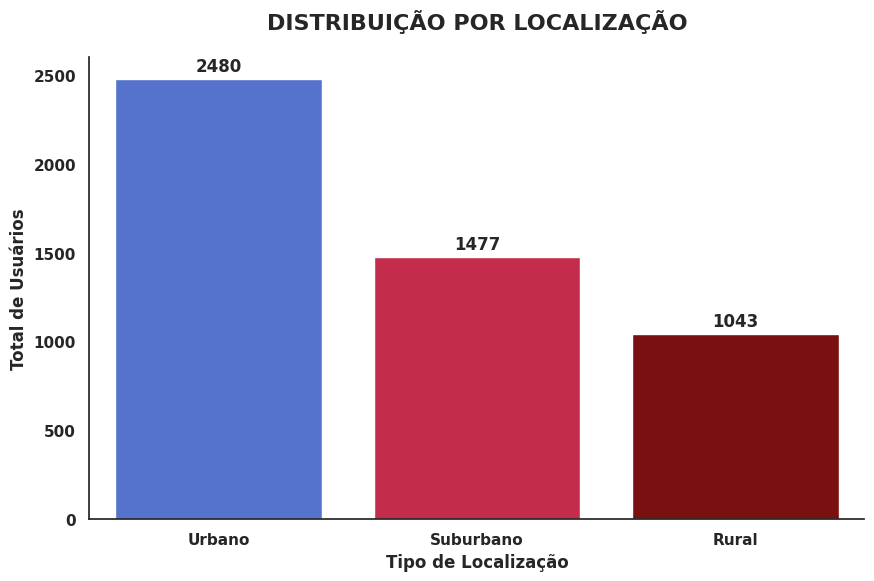

In [106]:
# @title
vermelho_escuro = '#8B0000'
azul_royal = '#4169E1'
vermelho_carmesim = '#DC143C'

mapeamento_local = {
    'Urban': 'Urbano',
    'Rural': 'Rural',
    'Suburban': 'Suburbano'
}

df_plot = df.copy()
df_plot['location_type'] = df_plot['location_type'].map(mapeamento_local)

plt.figure(figsize=(10, 6))
ordem_local = df_plot['location_type'].value_counts().index

#Criando o gráfico
ax = sns.countplot(data=df_plot, x='location_type', hue='location_type', order=ordem_local,
                   palette=[vermelho_escuro, azul_royal, vermelho_carmesim])

if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.title('DISTRIBUIÇÃO POR LOCALIZAÇÃO', fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Tipo de Localização', fontweight='bold', fontsize=12)
plt.ylabel('Total de Usuários', fontweight='bold', fontsize=12)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontweight='bold')

sns.despine()
plt.show()

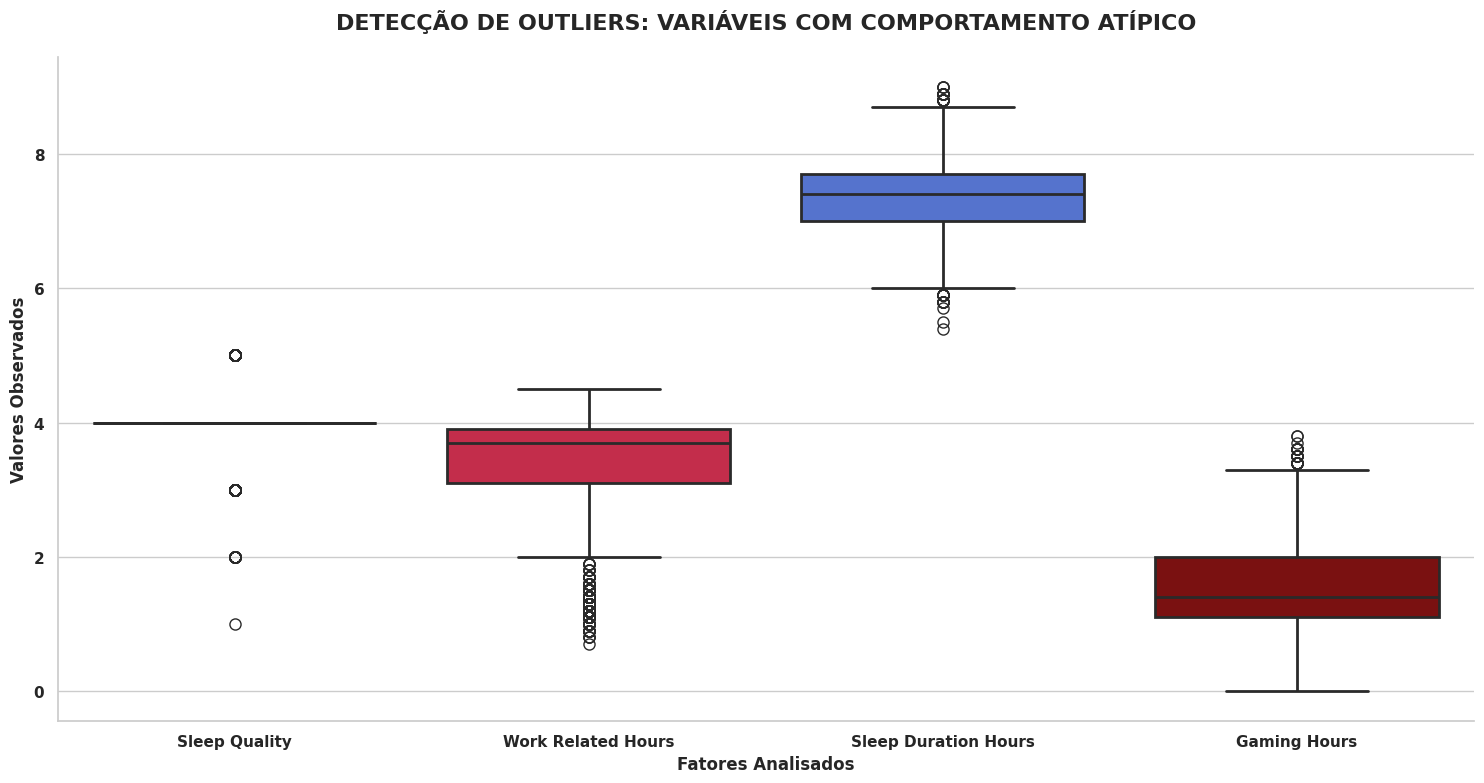

In [107]:
sns.set_theme(style="whitegrid")
colunas_outliers = ['sleep_quality', 'work_related_hours', 'sleep_duration_hours', 'gaming_hours']

#Criar a figura
plt.figure(figsize=(15, 8))

#Criar o Boxplot
ax = sns.boxplot(data=df[colunas_outliers],
                 palette=['#00008B', '#DC143C', '#4169E1', '#8B0000'],
                 fliersize=8,
                 linewidth=2)

plt.title('DETECÇÃO DE OUTLIERS: VARIÁVEIS COM COMPORTAMENTO ATÍPICO', fontweight='bold', fontsize=16, pad=20)
plt.ylabel('Valores Observados', fontweight='bold', fontsize=12)
plt.xlabel('Fatores Analisados', fontweight='bold', fontsize=12)

labels = [str(col).replace('_', ' ').title() for col in colunas_outliers]
plt.xticks(range(len(labels)), labels, fontweight='bold')
plt.yticks(fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

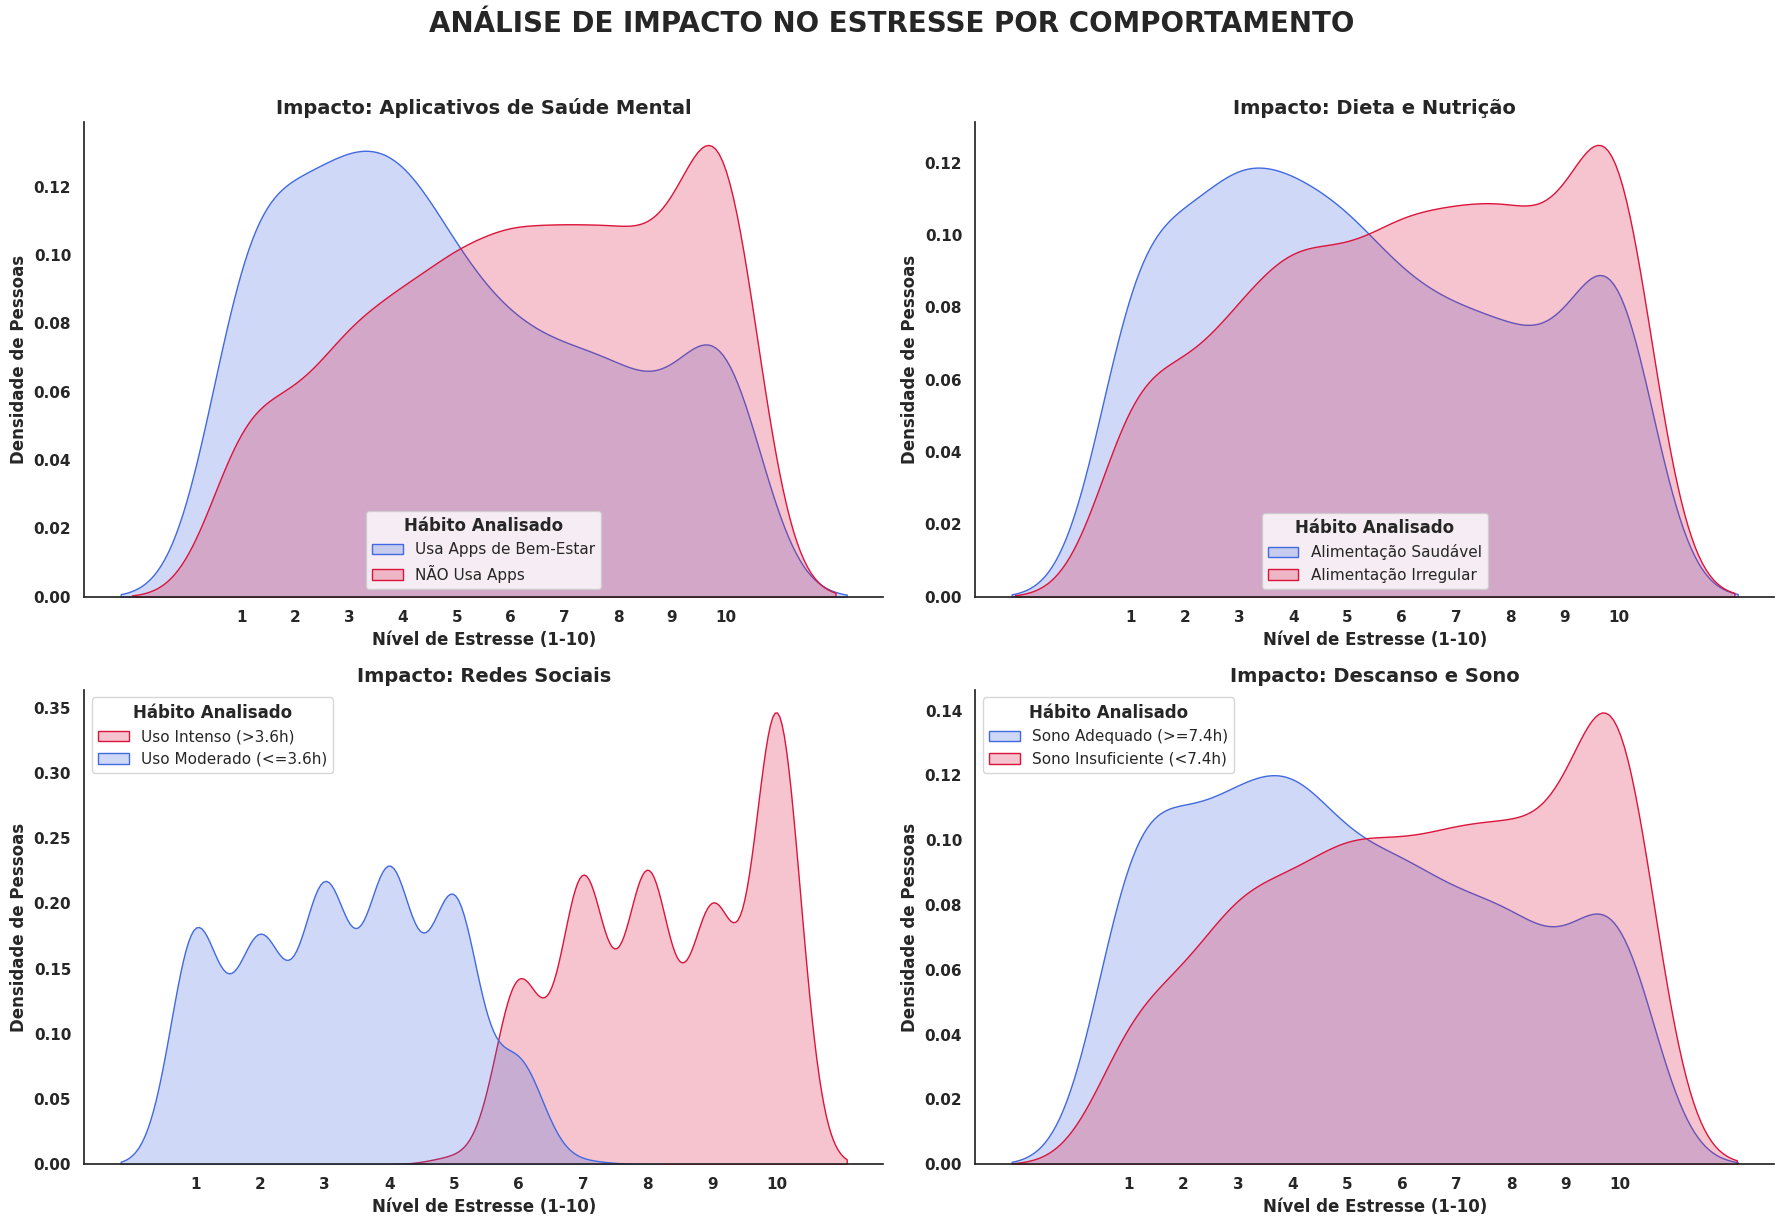

In [108]:
# @title
#Configuração do Painel (2 linhas e 2 colunas)
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('ANÁLISE DE IMPACTO NO ESTRESSE POR COMPORTAMENTO',
             fontsize=20, fontweight='bold', y=1.02)

cor_heroi = '#4169E1'
cor_vilao = '#DC143C'

#Medianas para divisão de grupos numéricos
mediana_social = df['social_media_hours'].median()
mediana_sono = df['sleep_duration_hours'].median()

#QUADRANTE 1: APPS DE BEM-ESTAR (HERÓI)
sns.kdeplot(data=df[df['uses_wellness_apps'] == True], x='stress_level', fill=True, color=cor_heroi,
            label='Usa Apps de Bem-Estar', ax=axes[0, 0], bw_adjust=1.2)
sns.kdeplot(data=df[df['uses_wellness_apps'] == False], x='stress_level', fill=True, color=cor_vilao,
            label='NÃO Usa Apps', ax=axes[0, 0], bw_adjust=1.2)
axes[0, 0].set_title('Impacto: Aplicativos de Saúde Mental', fontweight='bold', fontsize=14)

#QUADRANTE 2: ALIMENTAÇÃO SAUDÁVEL (HERÓI)
sns.kdeplot(data=df[df['eats_healthy'] == True], x='stress_level', fill=True, color=cor_heroi,
            label='Alimentação Saudável', ax=axes[0, 1], bw_adjust=1.2)
sns.kdeplot(data=df[df['eats_healthy'] == False], x='stress_level', fill=True, color=cor_vilao,
            label='Alimentação Irregular', ax=axes[0, 1], bw_adjust=1.2)
axes[0, 1].set_title('Impacto: Dieta e Nutrição', fontweight='bold', fontsize=14)

#QUADRANTE 3: REDES SOCIAIS (VILÃO)
sns.kdeplot(data=df[df['social_media_hours'] > mediana_social], x='stress_level', fill=True, color=cor_vilao,
            label=f'Uso Intenso (>{mediana_social}h)', ax=axes[1, 0], bw_adjust=1.2)
sns.kdeplot(data=df[df['social_media_hours'] <= mediana_social], x='stress_level', fill=True, color=cor_heroi,
            label=f'Uso Moderado (<={mediana_social}h)', ax=axes[1, 0], bw_adjust=1.2)
axes[1, 0].set_title('Impacto: Redes Sociais', fontweight='bold', fontsize=14)

#QUADRANTE 4: HORAS DE SONO (HERÓI)
sns.kdeplot(data=df[df['sleep_duration_hours'] >= mediana_sono], x='stress_level', fill=True, color=cor_heroi,
            label=f'Sono Adequado (>={mediana_sono}h)', ax=axes[1, 1], bw_adjust=1.2)
sns.kdeplot(data=df[df['sleep_duration_hours'] < mediana_sono], x='stress_level', fill=True, color=cor_vilao,
            label=f'Sono Insuficiente (<{mediana_sono}h)', ax=axes[1, 1], bw_adjust=1.2)
axes[1, 1].set_title('Impacto: Descanso e Sono', fontweight='bold', fontsize=14)

for ax in axes.flat:
    ax.set_xlabel('Nível de Estresse (1-10)', fontweight='bold')
    ax.set_ylabel('Densidade de Pessoas', fontweight='bold')
    ax.set_xticks(range(1, 11))
    ax.legend(title='Hábito Analisado', title_fontproperties={'weight':'bold'})
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontweight('bold')

sns.despine()
plt.tight_layout()
plt.show()

# **Análise de Impacto: Fatores Comportamentais vs. Níveis de Estresse**


Este painel comparativo utiliza a Estimativa de Densidade por Kernel (KDE) para contrastar grupos de usuários com hábitos opostos.



> **Interpretação dos Quadrantes Técnicos:**
Impacto Tecnológico e Nutricional (Quadrantes Superiores): Observa-se a eficácia de intervenções como o uso de Aplicativos de Bem-Estar e a manutenção de uma Dieta Saudável. No gráfico, o deslocamento da curva azul (Heróis) para a esquerda indica uma maior concentração de pessoas com baixos níveis de estresse, enquanto a curva vermelha revela uma dispersão maior rumo ao esgotamento.



> **Determinantes Biológicos e Sociais (Quadrantes Inferiores):** Utilizando a mediana como ponto de corte, estratificamos a amostra entre uso intenso de Redes Sociais e privação de Sono. A sobreposição das curvas permite quantificar visualmente o risco: grupos com sono insuficiente ou uso excessivo de telas apresentam picos de densidade deslocados para a direita, confirmando a correlação direta com níveis elevados de estresse.

> **Interpretação dos Quadrantes Técnicos:**
Impacto Tecnológico e Nutricional (Quadrantes Superiores): Observa-se a eficácia de intervenções como o uso de Aplicativos de Bem-Estar e a manutenção de uma Dieta Saudável. No gráfico, o deslocamento da curva azul (Heróis) para a esquerda indica uma maior concentração de pessoas com baixos níveis de estresse, enquanto a curva vermelha revela uma dispersão maior.

# **Método do Cotovelo**

A determinação do número ideal de agrupamentos fundamenta-se na aplicação do Método do Cotovelo (Elbow Method), técnica que analisa a variação da Inércia Total ou Soma dos Quadrados Dentro dos Clusters (Within-Cluster Sum of Squares - WCSS) em função do aumento do número de centros.

# **Critério do Ponto de Inflexão**

A escolha de $k=3$ justifica-se pela identificação do ponto de inflexão na curva de inércia. Observa-se que, até este valor, ocorre uma redução acentuada na dispersão interna dos grupos, indicando um ganho na homogeneidade de cada perfil. A partir de $k=3$, a queda da inércia torna-se marginal, o que sugere que a adição de novos grupos não resultaria em uma melhoria substancial na segmentação, apenas em um aumento desnecessário da complexidade do modelo.

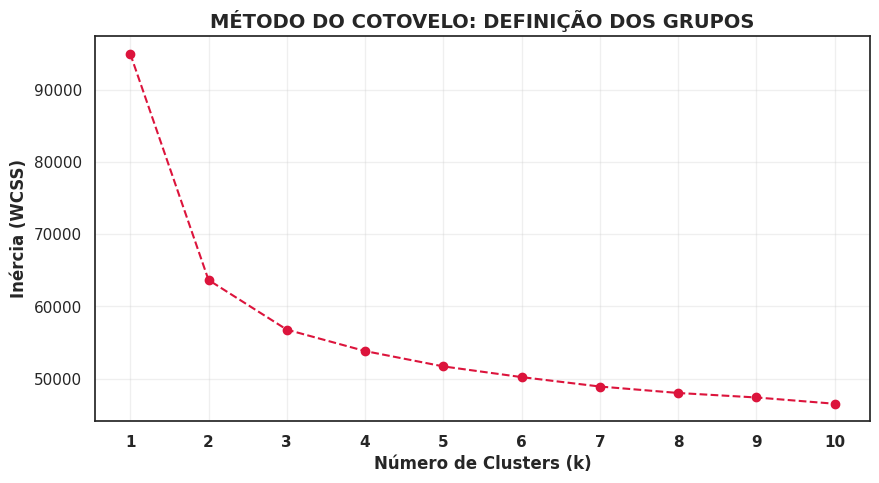

In [109]:
wcss = []
#Testamos de 1 a 10 grupos
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_normalizado) #Usando os dados já normalizados
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='#DC143C')
plt.title('MÉTODO DO COTOVELO: DEFINIÇÃO DOS GRUPOS', fontweight='bold', fontsize=14)
plt.xlabel('Número de Clusters (k)', fontweight='bold')
plt.ylabel('Inércia (WCSS)', fontweight='bold')
plt.xticks(range(1, 11), fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# **Algoritmo K-Means**

O K-Means é um dos algoritmos mais populares de Aprendizado de Máquina Não Supervisionado (Unsupervised Learning) voltado para a Análise de Grupos (Clustering). O seu principal objetivo é organizar um conjunto de dados em *k* grupos (clusters) distintos, onde os indivíduos dentro de cada grupo possuem características muito semelhantes entre si, mas são muito diferentes dos indivíduos dos outros grupos.

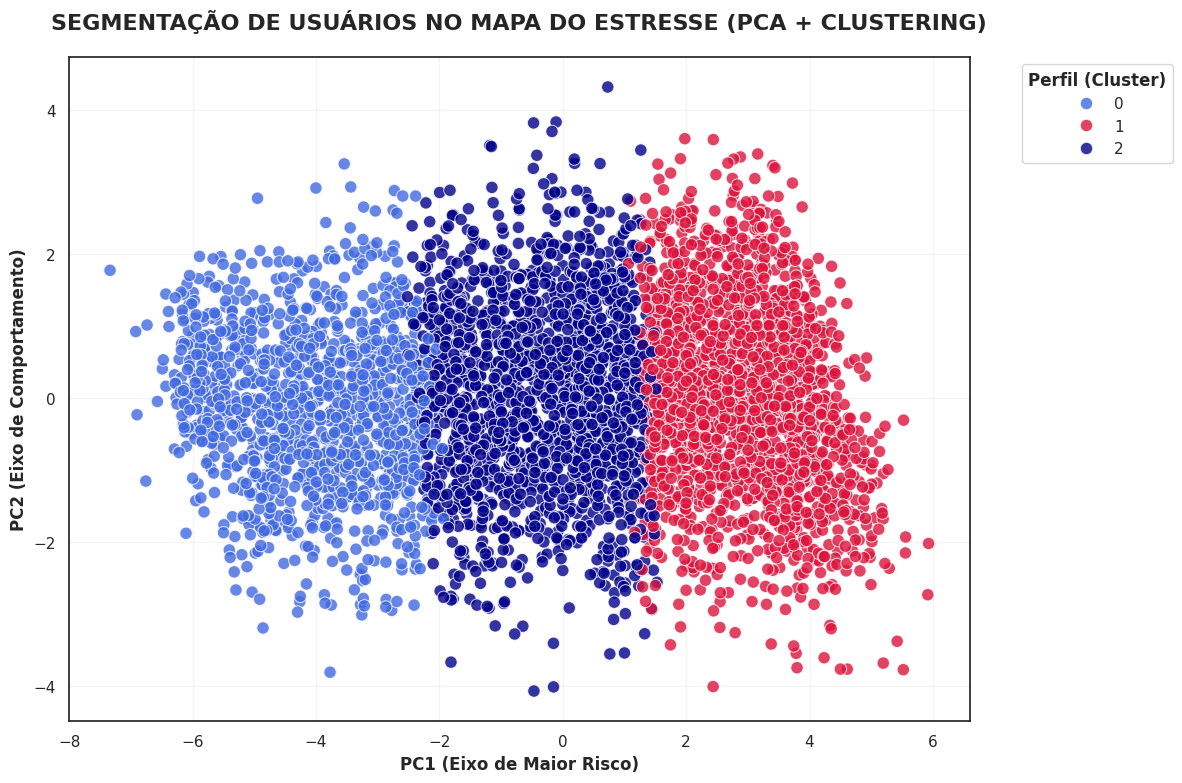

In [110]:
# @title
#Rodando o modelo
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(df_normalizado)

cores_vivas = ['#4169E1', '#DC143C', '#00008B']

#Usando as componentes PC1 e PC2
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=df_pca['PC1'],
    y=df_pca['PC2'],
    hue=df['cluster'],
    palette=cores_vivas,
    s=80,
    alpha=0.8,
    edgecolor='w'
)

plt.title('SEGMENTAÇÃO DE USUÁRIOS NO MAPA DO ESTRESSE (PCA + CLUSTERING)', fontweight='bold', fontsize=16, pad=20)
plt.xlabel('PC1 (Eixo de Maior Risco)', fontweight='bold', fontsize=12)
plt.ylabel('PC2 (Eixo de Comportamento)', fontweight='bold', fontsize=12)

plt.legend(title='Perfil (Cluster)', title_fontproperties={'weight':'bold'}, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# **A Análise de Componentes Principais (PCA)**

O PCA sintetizou a variabilidade dos dados em dois eixos ortogonais. O PC1 (Eixo de riscos) concentra a maior carga de variância relacionada ao impacto mental. O PC2 (Eixo de Perfil Comportamental) reflete as variações de estilo de vida e fatores demográficos. Esta redução de dimensionalidade permite uma visualização clara da estrutura dos dados, mitigando ruídos e evidenciando a separação natural da amostra.

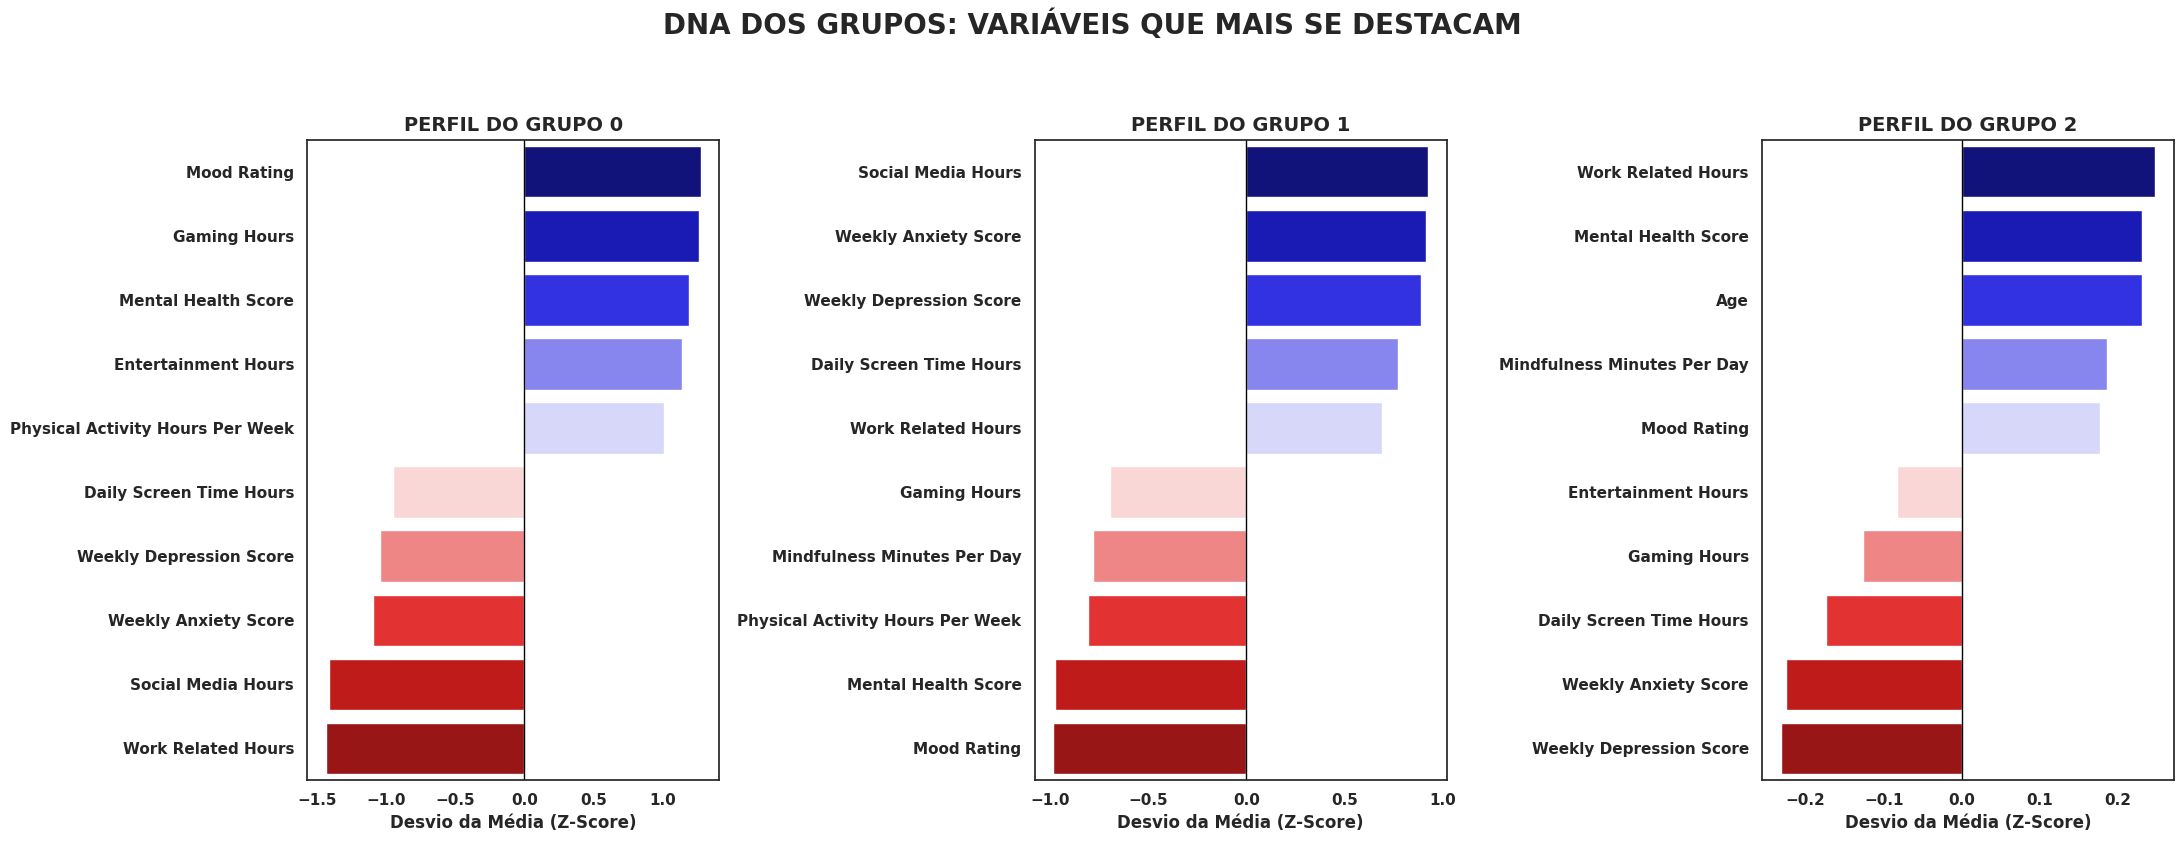

In [111]:
#Calculando a importância de cada variável por cluster (Desvio da Média)
#Usamos df_normalizado porque ele coloca todas as variáveis na mesma escala
resumo_cluster = df_normalizado.copy()
resumo_cluster['Cluster'] = df['cluster'].values
perfil_medio = resumo_cluster.groupby('Cluster').mean()

#Configurando a figura para 3 gráficos (um para cada cluster)
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('DNA DOS GRUPOS: VARIÁVEIS QUE MAIS SE DESTACAM', fontsize=20, fontweight='bold', y=1.05)

cores_clusters = ['#4169E1', '#DC143C', '#00008B'] # Azul Royal, Vermelho, Azul Escuro

for i in range(3):
    #Selecionando as 5 maiores e 5 menores características do cluster
    dados_cluster = perfil_medio.loc[i].sort_values(ascending=False)
    top_bottom = pd.concat([dados_cluster.head(5), dados_cluster.tail(5)])

    nomes_bonitos = [n.replace('_', ' ').title() for n in top_bottom.index]

    #Plotagem
    sns.barplot(x=top_bottom.values, y=nomes_bonitos, ax=axes[i], palette='seismic', hue=nomes_bonitos, legend=False)

    axes[i].set_title(f'PERFIL DO GRUPO {i}', fontweight='bold', fontsize=14)
    axes[i].set_xlabel('Desvio da Média (Z-Score)', fontweight='bold')
    axes[i].axvline(0, color='black', linewidth=1)

    for label in (axes[i].get_xticklabels() + axes[i].get_yticklabels()):
        label.set_fontweight('bold')

plt.tight_layout()
plt.show()

# **Classificacão de Dados**

# **Separação dos Dados e Divisão Holdout (70/30)**

Nesta etapa, preparamos os dados para o treinamento dos modelos de Machine Learning. Primeiro, separamos o conjunto de dados em duas partes:


> **Variáveis Preditoras (X):** Utilizamos o df_normalizado, que contém as características do estilo de vida e hábitos digitais já em uma escala padronizada (crucial para algoritmos baseados em distância, como o K-NN e o SVM).


> **Variável Alvo (y):** Isolamos a coluna stress_level da base original limpa (df), que é o comportamento que queremos prever.



In [112]:
#X recebe as features já padronizadas (sem a coluna target)
X = df_normalizado

#Y recebe exclusivamente o target da base limpa
y = df['stress_level']

#Divisão Holdout: 70% para Treinamento e 30% para Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# **Modelo K-NN (K-Nearest Neighbors)**

O K-NN (K-Nearest Neighbors) é um algoritmo que classifica um novo registro com base na categoria predominante dos seus k vizinhos mais próximos, ou seja, os perfis de dados mais semelhantes a ele. A normalização é necessária para colocar todas as variáveis na mesma proporção, evitando que características com valores numéricos altos dominem o cálculo de distância e distorçam a escolha de quem são esses vizinhos.

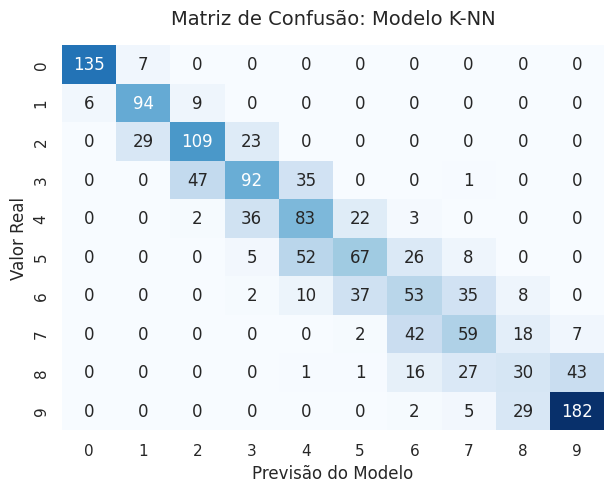

In [113]:
#Inicializar e treinar o K-NN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

#A variável que estava faltando
y_pred_knn = knn_model.predict(X_test)

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            cbar=False, annot_kws={"size": 12})

plt.title('Matriz de Confusão: Modelo K-NN', fontsize=14, pad=15)
plt.xlabel('Previsão do Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)

plt.show()

O modelo acertou nos extremos da base de dados, identificando 135 indivíduos com nível de estresse 1 e 182 com o nível máximo 10. Nos níveis intermediários o desempenho também foi alto, com 94 acertos exatos no nível 2. Quando o algoritmo falhou, o desvio foi muito pequeno, como prever que 6 pessoas eram nível 1 e 9 pessoas eram nível 3, quando na realidade todas eram nível 2. Estes números provam que o método é seguro e coerente, pois não comete erros graves e as suas falhas limitam-se a apenas um ponto de diferença na escala de estresse.

# **Modelo SVM - (Support Vector Machine)**

O SVM (Support Vector Machine) é um algoritmo que classifica os dados ao encontrar a melhor fronteira de separação (o hiperplano) entre as diferentes categorias, garantindo a maior margem de segurança possível entre elas. O motivo da divisão Holdout (70/30) é treinar o algoritmo com a maior parte dos dados (70%) e reservar uma amostra inédita (30%) para testar se ele realmente aprendeu a separar as classes de forma correta. Por fim, o motivo da Validação Cruzada (10 Folds) é repetir este processo de avaliação dividindo a base inteira em 10 partes diferentes, assegurando que o desempenho do modelo é consistente e não resulta apenas de uma divisão aleatória que o tenha favorecido.

RESULTADOS SVM (HOLDOUT)
Acurácia: 0.8527
F1 Score (Weighted): 0.8504

RESULTADOS SVM (CROSS-VALIDATION k=10)
Acurácia Média: 0.8552



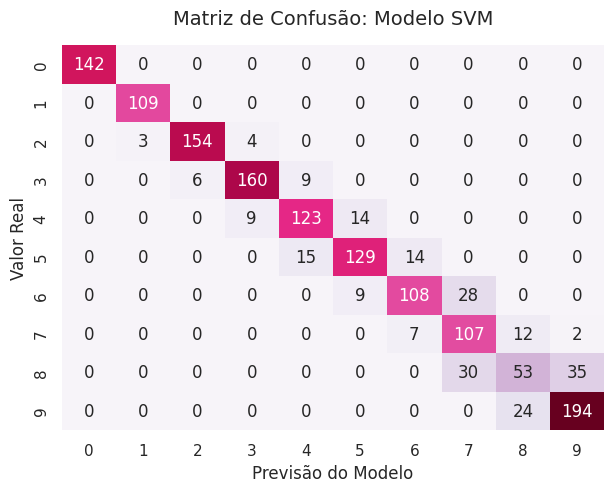

In [114]:
# @title
#Inicializar o SVM (utilizando kernel linear)
svm_model = SVC(kernel='linear', random_state=42)

#Treinamento com o método Holdout
svm_model.fit(X_train, y_train)

#Predição no conjunto de teste
y_pred_svm = svm_model.predict(X_test)

#Exibir as Métricas Numéricas (Holdout e Cross-Validation)
print("RESULTADOS SVM (HOLDOUT)")
print(f"Acurácia: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"F1 Score (Weighted): {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")

cv_scores_svm = cross_val_score(svm_model, X, y, cv=10, scoring='accuracy')
print("\nRESULTADOS SVM (CROSS-VALIDATION k=10)")
print(f"Acurácia Média: {cv_scores_svm.mean():.4f}\n")

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='PuRd',
            cbar=False, annot_kws={"size": 12})

plt.title('Matriz de Confusão: Modelo SVM', fontsize=14, pad=15)
plt.xlabel('Previsão do Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)

plt.show()

In [1]:
# Inicializando e treinando a Árvore de Decisão
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# Predição
y_pred_tree = tree_model.predict(X_test)

# Métricas Árvore de Decisão
print("\n--- Métricas Árvore de Decisão (Holdout) ---")
print("Acurácia:", accuracy_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree, average='weighted'))
print("\nMatriz de Confusão Árvore:\n", confusion_matrix(y_test, y_pred_tree))

# Validação Cruzada (k=10) para a Árvore de Decisão
scores_tree = cross_val_score(tree_model, X, y, cv=10, scoring='accuracy')
print("\nAcurácia média Árvore (Cross-Validation k=10):", scores_tree.mean())

NameError: name 'DecisionTreeClassifier' is not defined

In [115]:
# @title
from math import sqrt

def cal_dist_euclideana(vet1, vet2):
  distancia = 0
  for i in range(len(vet1)-1):
      distancia += (vet1[i] - vet2[i])**2
  distancia = sqrt(distancia)
  return distancia

def retorna_vizinhos(base_treinamento, amostra_teste, k):
  distancias = list()
  for amostra_treinamento in base_treinamento:
    dist = cal_dist_euclideana(amostra_treinamento, amostra_teste)
    distancias.append((amostra_treinamento,dist))

  #Ordenação pela distância de forma crescente
  distancias.sort(key=lambda tup: tup[1])
  vizinhos = list()
  for i in range(k):
    vizinhos.append(distancias[i][0])
  return vizinhos


def classificacao(base_treinamento, amostra_teste, k):
  vizinhos = retorna_vizinhos(base_treinamento, amostra_teste, k)
  rotulos = [v[-1] for v in vizinhos]
  predicao = max(set(rotulos), key=rotulos.count)
  return predicao

dataset = [ [2.7, 2.5, 0], [1.4, 2.3, 0], [3.3, 4.4, 0], [1.3, 1.8, 0], [3,3,0], [7.6, 2.7,1], [5.3, 2,1], [6.9,1.7,1], [8.6, -0.2, 1], [7.6,3.5,1]]
amostra = [7,7,0]
predicao = classificacao(dataset,amostra,3)
print('Resultado Classifição')
print('Esperado: %d\nPredição: %d' % (amostra[-1], predicao))

Resultado Classifição
Esperado: 0
Predição: 1
